# Citi Bike Station Network — Network Science Group Project

**Course:** Network Science  
**Dataset:** NYC Citi Bike trips (station–station flows)  
**Notebook:** Core analysis for Outcomes A–G  

**Team members:**  
- Kranthi Teja **(Section E and G)**
- Rithwik Reddy **(Section A, B, C)**
- Linh Ngo **(Section D and F)**

This notebook implements our group project on the Citi Bike station network.  
Each trip is treated as a directed interaction from a start station to an end station, 
which lets us build a directed, weighted, time-evolving network of stations.


## 0. Project Overview

**Goal.** Use Network Science tools to analyse the Citi Bike station network as a directed, weighted, time-evolving graph.  
We focus on:

- Baseline structure of the station network (size, density, connectivity).  
- Hubs and influential stations/corridors.  
- Community structure (riding “neighbourhoods”).  
- Imbalance and operational stress on stations.  
- Resilience under failures and percolation-style attacks.  
- Link prediction and emerging corridors.  
- Temporal evolution of structure, hubs, and communities over months/slices.

This notebook is the main technical artifact that supports the written PDF report.  
Plots and tables here are referenced in the report where appropriate.


## 0.1 Dataset & Preprocessing

**Original data source.** Citi Bike trip data is publicly available at the official portal:  
[https://s3.amazonaws.com/tripdata/index.html](https://s3.amazonaws.com/tripdata/index.html)

This site hosts monthly trip files in CSV format. Each row corresponds to a single trip with
start/end station information, timestamps, and station coordinates.

**Project dataset.** For this project, we use a cleaned / merged CSV prepared by Rithwik (team member),  
who combined **four consecutive months** of Citi Bike trip data into a single file to simplify analysis:

[2025-citibike-tripdata.csv (OU O-Cloud link)](https://sooners-my.sharepoint.com/:x:/r/personal/rithwikreddyd_ou_edu/_layouts/15/Doc.aspx?sourcedoc=%7B8735350F-BDCE-4D42-B59E-7C868012E8F3%7D&file=2025-citibike-tripdata.csv&fromShare=true&action=default&mobileredirect=true)

Access to this file requires OU credentials via the **O Cloud / OneDrive** environment.

**Network view.**

- Each *station* is a node.  
- Each ordered station pair (start → end) is a directed edge.  
- Edge weight = number of trips between that ordered pair in the chosen time window.

**Time slicing.**

- We primarily work with a subset of months (merged into the single CSV above),  
  and when needed we construct per-month graphs or other time slices (e.g., weekday vs weekend, dayparts)
  using the same pipeline.  

**Core cleaning steps (high level).**

- Drop trips with missing start or end station ID.  
- Ensure `station_id` is treated consistently as an ID (not as a float) so joins across outcomes work.  
- Filter out obviously invalid coordinates when present.  
- Aggregate trips into weighted edges for each graph (full merged file, per month, or per slice).

Implementation details of loading and cleaning are shown in the first code cells of Outcome A.


## 0.2 Outcomes & Notebook Roadmap

The project plan defines Outcomes A–H. In this notebook we focus on A–G: 

- **Outcome A — Network Structure & Statistics**  
  Baseline station network properties: size, density, degree/strength distributions,  
  SCC/WCC structure, shortest paths and diameter, clustering, reciprocity, and small-world indicators.

- **Outcome B — Hubs and Influence**  
  Centrality analysis (in/out strength, PageRank, eigen-style scores, betweenness)  
  to identify key hubs, bridges, and major corridors.

- **Outcome C — Community Structure**  
  Community detection on the weighted station graph to find riding neighbourhoods,  
  modularity, community sizes, and inter-community flows.

- **Outcome D — Imbalance & Operational Stress**  
  Station-level arrivals vs departures, imbalance, volatility, and rebalancing pressure.

- **Outcome E — Resilience & Percolation**  
  Random and targeted station removals, giant component size, reachability,  
  and path-length changes versus fraction of removed nodes.

- **Outcome F — Network Inference / Link Prediction**  
  Structural predictors (e.g., common neighbours, Adamic–Adar, preferential attachment)  
  to flag potential emerging corridors and new station-station links.

- **Outcome G — Dynamic & Temporal Patterns**  
  Temporal evolution of structure, hubs, and communities across months/slices  
  (e.g., stability of hubs, changing community sizes, shifting modularity).




## 0.3 Reproducibility & Conventions

To keep the analysis consistent across A–G and across team members, we follow the shared pipeline from the audit document:  

**ID and schema conventions**

- Use `station_id` as the primary key everywhere (not `station_name`).  
- Use a shared `station_metadata` table: `station_id`, `station_name`, `lat`, `lng`.  
- Monthly / slice-specific outputs include a `month_label` and/or `slice_label`.

**Graph construction**

- Directed weighted graph for core flow analysis.  
- Symmetrized undirected graph when required (clustering, some community methods).  
- Per-month or per-slice graphs are built using the same cleaning pipeline as the full graph.

**Randomness and parameters**

- Where algorithms involve randomness (e.g., community detection), we fix seeds in code when possible.  
- We keep track of key hyperparameters (e.g., top-K hubs, thresholds, slice definitions)  
  in variables near the top of each section so reruns are easy.

**How to run this notebook**

1. Run the import and data-loading cells at the top of Outcome A.  
2. Then run sections **A**, **B**, **C**, … in order.  
3. Plots and tables produced here are the basis for the figures and discussion in the written report.


In [81]:
# --- Consolidated Imports for the Notebook ---

import random                  # for generating random orders or shuffling lists
import numpy as np             # numerical operations, arrays, scaling values
import networkx as nx          # graph/network analysis (nodes, edges, connectivity)
import pandas as pd            # data manipulation and tabular structures (DataFrames)
import matplotlib.pyplot as plt # static plotting and visualization
import plotly.graph_objects as go # interactive map-based visualizations (Scattermapbox, etc.)

Combined shape: (3724596, 15)
  start_station_id end_station_id
0          6182.02        5746.02
1          6182.02        6004.07
2          5238.05        5137.11
3          5238.05        5137.11
4          6197.08        5414.06
Number of distinct directed edges: 552891
  start_station_id end_station_id   w
0       190 Morgan        4054.06   1
1       190 Morgan        4131.03   1
2          2733.03        2782.02   8
3          2733.03        2821.05   4
4          2733.03        2832.03  11
Graph nodes: 2298
Graph edges: 552891

Outcome A: Combined 4-Month Network
nodes_N: 2298
edges_M: 552891
density: 0.10474384229173937
avg_in_degree: 240.59660574412533
avg_out_degree: 240.59660574412533
avg_in_strength: 1591.8137510879026
avg_out_strength: 1591.8137510879026
reciprocity: 0.6359770732386673
num_WCC: 2
giant_WCC_size: 2296
num_SCC: 71
giant_SCC_size: 2228
avg_shortest_path_GSCC: 2.113609576932038
diameter_GSCC: 5
transitivity: 0.51838757166744
avg_clustering: 0.500812518047842

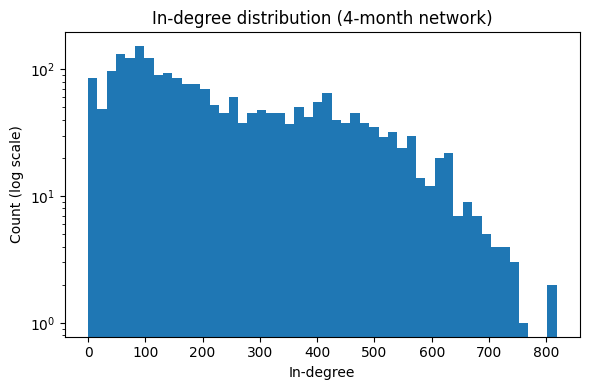

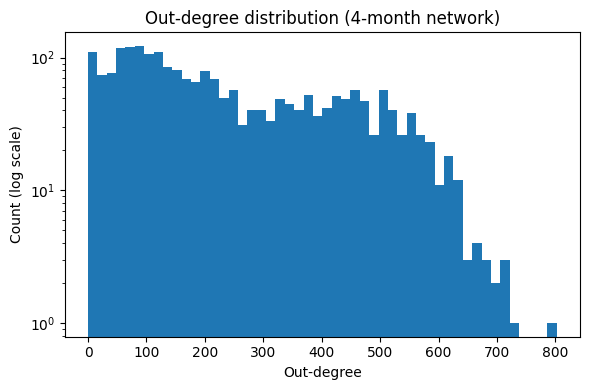

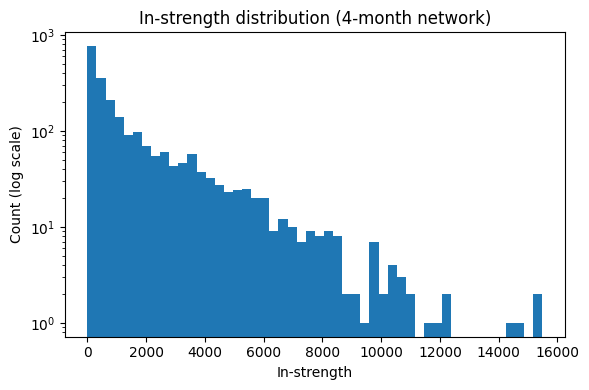

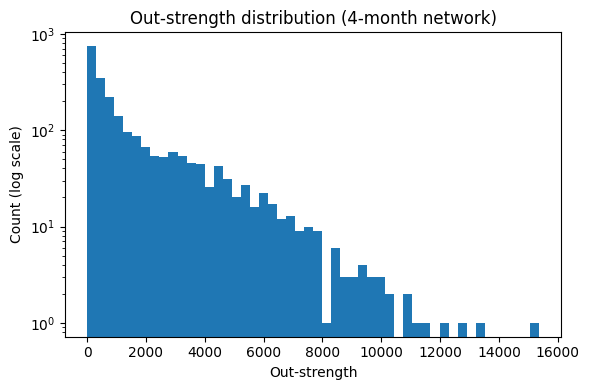


Per-month baseline statistics:
         nodes_N  edges_M   density  avg_in_degree  avg_out_degree  \
month                                                                
2024-12      249      151  0.002445       0.606426        0.606426   
2025-01     2191   272216  0.056732     124.242812      124.242812   
2025-02     2203   274980  0.056685     124.820699      124.820699   
2025-03     2254   279960  0.055129     124.205856      124.205856   
2025-04     2256   211712  0.041616      93.843972       93.843972   

         avg_in_strength  avg_out_strength  reciprocity  num_WCC  \
month                                                              
2024-12         0.662651          0.662651     0.000000       99   
2025-01       448.260612        448.260612     0.587460        1   
2025-02       446.710395        446.710395     0.588610        2   
2025-03       436.755102        436.755102     0.486584        1   
2025-04       313.446365        313.446365     0.337364        1   



In [82]:
# Outcome A: Network Structure & Statistics

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load combined 4-month dataset
csv_files = [
    "C:/Users/krant/Downloads/2025-citibike-tripdata.csv"
]

dfs = []
for path in csv_files:
    # Read station IDs as strings to avoid float parsing issues across months
    df = pd.read_csv(
        path,
        low_memory=False,
        dtype={
            "start_station_id": "string",
            "end_station_id": "string"
        }
    )
    df["source_file"] = Path(path).stem
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

print("Combined shape:", df_all.shape)
print(df_all[["start_station_id", "end_station_id"]].head())

# Parse timestamps
df_all["started_at"] = pd.to_datetime(df_all["started_at"])
df_all["ended_at"] = pd.to_datetime(df_all["ended_at"])

# Extract month label for per-month baseline stats
df_all["month_label"] = df_all["started_at"].dt.to_period("M").astype(str)

# Basic data sanity filtering:
#  - drop rows without valid station IDs
df_all = df_all.dropna(subset=["start_station_id", "end_station_id"])

# 2. Build directed weighted edge list for the combined network
#    We drop self-loops here (trips that start and end at the same station)
edges_all = (
    df_all
    .loc[df_all["start_station_id"] != df_all["end_station_id"], ["start_station_id", "end_station_id"]]
    .groupby(["start_station_id", "end_station_id"])
    .size()
    .reset_index(name="w")
)

print("Number of distinct directed edges:", len(edges_all))
print(edges_all.head())

# 3. Build directed weighted graph
G_all = nx.DiGraph()
for _, r in edges_all.iterrows():
    G_all.add_edge(r["start_station_id"], r["end_station_id"], weight=float(r["w"]))

print("Graph nodes:", G_all.number_of_nodes())
print("Graph edges:", G_all.number_of_edges())

# Helper to symmetrize for clustering / community work
def symmetrize_graph(G):
    """Convert directed weighted graph to undirected weighted graph
    by summing reciprocal weights."""
    U = nx.Graph()
    for u, v, data in G.edges(data=True):
        w = data.get("weight", 1.0)
        if U.has_edge(u, v):
            U[u][v]["weight"] += w
        else:
            U.add_edge(u, v, weight=w)
    return U

# 4. Outcome A metrics function
def compute_outcome_A(G):
    results = {}

    N = G.number_of_nodes()
    M = G.number_of_edges()
    results["nodes_N"] = N
    results["edges_M"] = M
    results["density"] = M / (N * (N - 1)) if N > 1 else np.nan

    # Degree & strength
    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    in_str  = dict(G.in_degree(weight="weight"))
    out_str = dict(G.out_degree(weight="weight"))

    results["avg_in_degree"]   = np.mean(list(in_deg.values())) if N else np.nan
    results["avg_out_degree"]  = np.mean(list(out_deg.values())) if N else np.nan
    results["avg_in_strength"] = np.mean(list(in_str.values())) if N else np.nan
    results["avg_out_strength"] = results["avg_in_strength"]

    # Reciprocity
    try:
        results["reciprocity"] = nx.reciprocity(G)
    except Exception:
        results["reciprocity"] = np.nan

    # Components
    wcc_sizes = [len(c) for c in nx.weakly_connected_components(G)]
    results["num_WCC"] = len(wcc_sizes)
    results["giant_WCC_size"] = max(wcc_sizes) if wcc_sizes else 0

    scc_sizes = [len(c) for c in nx.strongly_connected_components(G)]
    results["num_SCC"] = len(scc_sizes)
    results["giant_SCC_size"] = max(scc_sizes) if scc_sizes else 0

    # Distances within giant SCC
    if scc_sizes and results["giant_SCC_size"] > 1:
        giant_scc_nodes = max(nx.strongly_connected_components(G), key=len)
        GSCC = G.subgraph(giant_scc_nodes).copy()
        try:
            results["avg_shortest_path_GSCC"] = nx.average_shortest_path_length(GSCC)
            results["diameter_GSCC"] = nx.diameter(GSCC)
        except Exception:
            results["avg_shortest_path_GSCC"] = np.nan
            results["diameter_GSCC"] = np.nan
    else:
        results["avg_shortest_path_GSCC"] = np.nan
        results["diameter_GSCC"] = np.nan

    # Clustering on symmetrized graph
    U = symmetrize_graph(G)
    if U.number_of_nodes() > 1 and U.number_of_edges() > 0:
        results["transitivity"]   = nx.transitivity(U)
        results["avg_clustering"] = nx.average_clustering(U)
    else:
        results["transitivity"]   = np.nan
        results["avg_clustering"] = np.nan

    return results, in_deg, out_deg, in_str, out_str

# 5. Run Outcome A on the combined graph
overall_res, in_deg_all, out_deg_all, in_str_all, out_str_all = compute_outcome_A(G_all)

print("\nOutcome A: Combined 4-Month Network")
for k, v in overall_res.items():
    print(f"{k}: {v}")

# 6. Degree & strength distribution plots (log-scale y-axis)
def plot_degree_strength(G, title_suffix=""):
    in_deg_vals = np.array([d for _, d in G.in_degree()])
    out_deg_vals = np.array([d for _, d in G.out_degree()])
    in_str_vals = np.array([s for _, s in G.in_degree(weight="weight")])
    out_str_vals = np.array([s for _, s in G.out_degree(weight="weight")])

    metrics = [
        (in_deg_vals, "In-degree"),
        (out_deg_vals, "Out-degree"),
        (in_str_vals, "In-strength"),
        (out_str_vals, "Out-strength"),
    ]

    for vals, name in metrics:
        plt.figure(figsize=(6,4))
        plt.hist(vals, bins=50, log=True)
        plt.xlabel(name)
        plt.ylabel("Count (log scale)")
        plt.title(f"{name} distribution {title_suffix}")
        plt.tight_layout()
        plt.show()

plot_degree_strength(G_all, "(4-month network)")

# 7. Per-month baseline stats (same metrics as Outcome A)
monthly_results = []

for month, df_m in df_all.groupby("month_label"):
    edges_m = (
        df_m
        .loc[df_m["start_station_id"] != df_m["end_station_id"], ["start_station_id", "end_station_id"]]
        .groupby(["start_station_id", "end_station_id"])
        .size()
        .reset_index(name="w")
    )

    G_m = nx.DiGraph()
    for _, r in edges_m.iterrows():
        G_m.add_edge(r["start_station_id"], r["end_station_id"], weight=float(r["w"]))

    res_m, _, _, _, _ = compute_outcome_A(G_m)
    res_m["month"] = month
    monthly_results.append(res_m)

df_monthly_stats = pd.DataFrame(monthly_results).set_index("month").sort_index()

print("\nPer-month baseline statistics:")
print(df_monthly_stats)


Top hubs by in-strength (4-month combined):
   station_id  in_strength
0     5329.03      15484.0
1     5905.14      15445.0
2     6726.01      14796.0
3     6140.05      14345.0
4     6072.11      12198.0
5     7059.08      12153.0
6     6450.05      11773.0
7     5779.11      11521.0
8     5788.13      10893.0
9     5989.02      10891.0
10    6492.08      10775.0
11    5303.08      10759.0
12    6306.06      10624.0
13    6331.01      10456.0
14    6876.04      10450.0
15    6459.04      10397.0
16    6602.03      10307.0
17    6230.02      10212.0
18    6098.10      10015.0
19    6072.06       9902.0

Top hubs by out-strength (4-month combined):
   station_id  out_strength
0     6140.05       15358.0
1     6233.04       13313.0
2     5788.13       12888.0
3     6331.01       12239.0
4     5905.12       11569.0
5     6492.08       11282.0
6     5905.14       11033.0
7     5779.11       11006.0
8     6726.01       10349.0
9     6364.07       10319.0
10    5303.06       10011.0
11    6

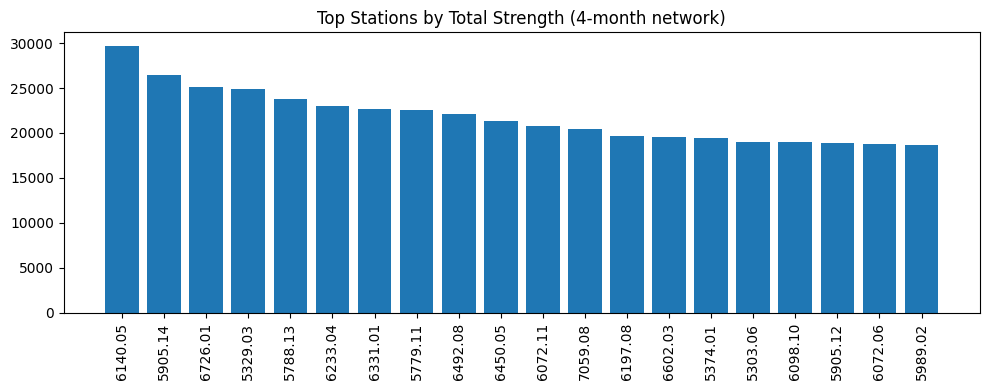

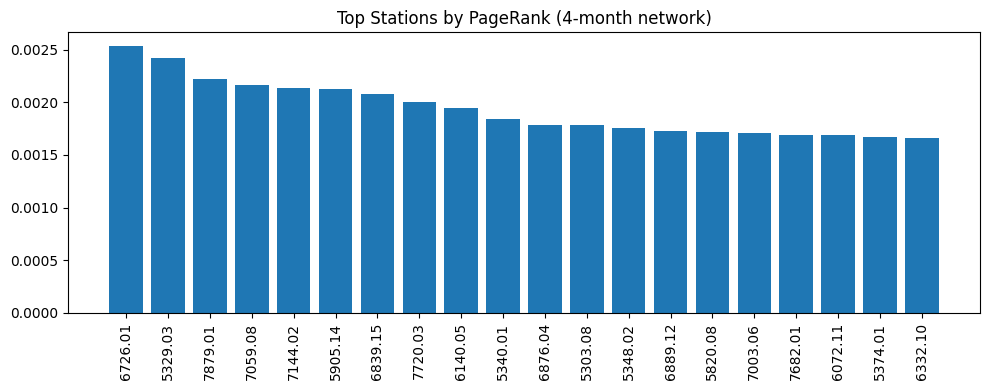

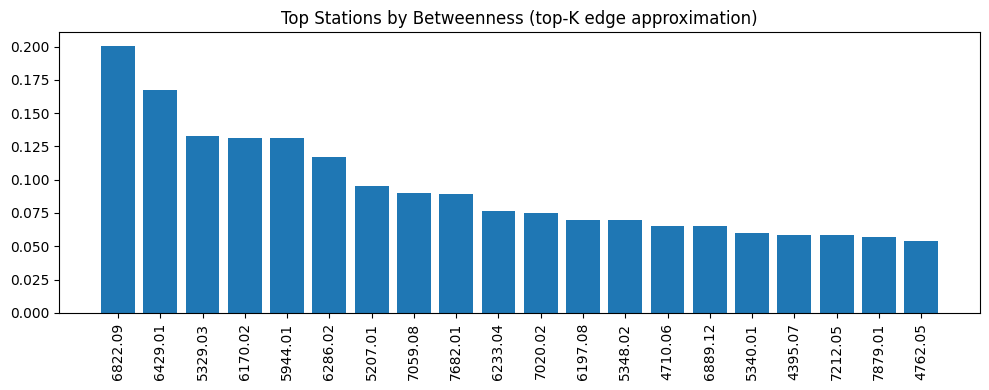

In [83]:
# Outcome B: Hubs, Corridors & Influence (Centrality)

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Strength-based hubs on combined 4-month network

# In-strength: total incoming trips per station
in_strength_sorted = sorted(in_str_all.items(), key=lambda x: x[1], reverse=True)
# Out-strength: total outgoing trips per station
out_strength_sorted = sorted(out_str_all.items(), key=lambda x: x[1], reverse=True)
# Total strength
total_strength = {node: in_str_all[node] + out_str_all[node] for node in G_all.nodes()}
total_strength_sorted = sorted(total_strength.items(), key=lambda x: x[1], reverse=True)

topN = 20
df_in_strength = pd.DataFrame(in_strength_sorted[:topN], columns=["station_id", "in_strength"])
df_out_strength = pd.DataFrame(out_strength_sorted[:topN], columns=["station_id", "out_strength"])
df_total_strength = pd.DataFrame(total_strength_sorted[:topN], columns=["station_id", "total_strength"])

print("Top hubs by in-strength (4-month combined):")
print(df_in_strength)
print("\nTop hubs by out-strength (4-month combined):")
print(df_out_strength)
print("\nTop hubs by total strength (4-month combined):")
print(df_total_strength)

# 2. PageRank hubs on combined 4-month network

pagerank_scores = nx.pagerank(G_all, alpha=0.85, max_iter=100, weight="weight")
pagerank_sorted = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)
df_pagerank = pd.DataFrame(pagerank_sorted[:topN], columns=["station_id", "pagerank"])

print("\nTop hubs by PageRank (4-month combined):")
print(df_pagerank)

# 3. Betweenness centrality (approximate, on top-K weighted edges)

# To keep runtime manageable on this dense graph, build an undirected graph
# using only the top-K heaviest edges and treat distance as 1/weight.
K_btw = 100000  # you can lower/raise this if runtime is an issue

edges_sorted = sorted(G_all.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)
edges_for_btw = edges_sorted[:K_btw]

U_btw = nx.Graph()
for u, v, data in edges_for_btw:
    w = data["weight"]
    if w <= 0:
        continue
    dist = 1.0 / w
    if U_btw.has_edge(u, v):
        # keep smallest distance (largest weight)
        U_btw[u][v]["weight"] = min(U_btw[u][v]["weight"], dist)
    else:
        U_btw.add_edge(u, v, weight=dist)

betw_scores = nx.betweenness_centrality(U_btw, weight="weight", normalized=True)
betw_sorted = sorted(betw_scores.items(), key=lambda x: x[1], reverse=True)
df_betweenness = pd.DataFrame(betw_sorted[:topN], columns=["station_id", "betweenness"])

print("\nTop hubs by betweenness (approx., using top-K edges):")
print(df_betweenness)

# 4. Top OD corridors (edges) by flow

# edges_all (from Outcome A) has start_station_id, end_station_id, w

top_corridorsN = 30
df_top_corridors = (
    edges_all
    .sort_values("w", ascending=False)
    .head(top_corridorsN)
    .reset_index(drop=True)
)

print("\nTop OD corridors by weight (4-month combined):")
print(df_top_corridors)

# 5. Cross-slice comparisons of hubs (per-month and weekday/weekend)

# Helper: compute strength table from a trips dataframe

def compute_strength_from_df(df_slice, slice_label):
    # count departures and arrivals
    out_counts = df_slice.groupby("start_station_id").size().rename("out_strength")
    in_counts  = df_slice.groupby("end_station_id").size().rename("in_strength")
    strength = pd.concat([in_counts, out_counts], axis=1).fillna(0)
    strength["total_strength"] = strength["in_strength"] + strength["out_strength"]
    strength = strength.sort_values("total_strength", ascending=False)
    strength["slice"] = slice_label
    strength = strength.reset_index().rename(columns={"index": "station_id"})
    return strength

# 5a. Hubs per month

monthly_hub_tables = {}

for month, df_m in df_all.groupby("month_label"):
    # drop rows with missing IDs just in case
    df_m = df_m.dropna(subset=["start_station_id", "end_station_id"])
    hubs_m = compute_strength_from_df(df_m, slice_label=month)
    monthly_hub_tables[month] = hubs_m
    print(f"\nTop 10 hubs by total strength in month {month}:")
    print(hubs_m.head(10))

# 5b. Weekday vs weekend hubs on the full 4-month window

df_all["is_weekend"] = df_all["started_at"].dt.dayofweek >= 5

weekday_df = df_all.loc[~df_all["is_weekend"]].copy()
weekend_df = df_all.loc[df_all["is_weekend"]].copy()

weekday_hubs = compute_strength_from_df(weekday_df, slice_label="weekday")
weekend_hubs = compute_strength_from_df(weekend_df, slice_label="weekend")

print("\nTop 10 hubs by total strength on weekdays (4-month window):")
print(weekday_hubs.head(10))

print("\nTop 10 hubs by total strength on weekends (4-month window):")
print(weekend_hubs.head(10))

# 6. Plots for top hubs on combined network

def plot_bar(df, col, title):
    plt.figure(figsize=(10,4))
    plt.bar(df["station_id"].astype(str), df[col])
    plt.xticks(rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_bar(df_total_strength, "total_strength", "Top Stations by Total Strength (4-month network)")
plot_bar(df_pagerank, "pagerank", "Top Stations by PageRank (4-month network)")
plot_bar(df_betweenness, "betweenness", "Top Stations by Betweenness (top-K edge approximation)")



Undirected graph for communities:
Nodes: 2298
Edges: 377078

Community detection results:
Method used: louvain
Number of communities: 8
Top community sizes: [474, 473, 399, 339, 329, 279, 3, 2]
Modularity score: 0.5452461847712569

Community summary (top 10):
   community_id  community_size
0             0             474
5             5             473
6             6             399
4             4             339
3             3             329
1             1             279
2             2               3
7             7               2

Modularity score: 0.5452461847712569

Tiny communities (size <= 3): [2, 7]

Top 15 community-to-community flows (by weight):
    source_comm  target_comm    weight
0             4            4  938417.0
1             1            1  798158.0
2             0            0  500299.0
3             3            3  297399.0
4             4            1  212997.0
5             1            4  197897.0
6             6            6  189044.0
7            

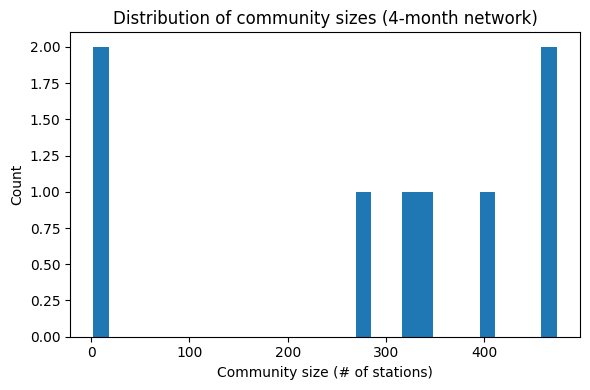

In [84]:

# Outcome C: Community Structure

from networkx.algorithms.community import greedy_modularity_communities
try:
    from networkx.algorithms.community import louvain_communities
    _has_louvain = True
except ImportError:
    _has_louvain = False
from networkx.algorithms.community.quality import modularity

# 1. Build undirected weighted graph for community detection

U_comm = symmetrize_graph(G_all)

print("\nUndirected graph for communities:")
print("Nodes:", U_comm.number_of_nodes())
print("Edges:", U_comm.number_of_edges())

# 2. Community detection

if _has_louvain:
    communities = list(louvain_communities(U_comm, weight="weight", seed=42))
    method_used = "louvain"
else:
    communities = list(greedy_modularity_communities(U_comm, weight="weight"))
    method_used = "greedy_modularity"

num_comms = len(communities)
sizes = [len(c) for c in communities]
sizes_sorted = sorted(sizes, reverse=True)

print("\nCommunity detection results:")
print("Method used:", method_used)
print("Number of communities:", num_comms)
print("Top community sizes:", sizes_sorted[:10])

mod_score = modularity(U_comm, communities, weight="weight")
print("Modularity score:", mod_score)

# 3. Station community mapping with correct sizes

node_to_comm = {}
for cid, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = cid

df_communities = pd.DataFrame({
    "station_id": list(node_to_comm.keys()),
    "community_id": list(node_to_comm.values())
})

comm_summary = (
    df_communities
    .groupby("community_id")
    .agg(community_size=("station_id", "count"))
    .reset_index()
    .sort_values("community_size", ascending=False)
)

# merge community_size back onto each station to avoid size-mapping bugs

df_communities = df_communities.merge(comm_summary, on="community_id", how="left")

print("\nCommunity summary (top 10):")
print(comm_summary.head(10))
print("\nModularity score:", mod_score)

# Identify tiny communities (size <= 3) as likely outliers

tiny_comms = comm_summary.loc[comm_summary["community_size"] <= 3, "community_id"].tolist()
print("\nTiny communities (size <= 3):", tiny_comms)

# 4. Community-to-community flows from directed graph G_all

node_to_comm_map = df_communities.set_index("station_id")["community_id"].to_dict()

comm_flow = {}
for u, v, data in G_all.edges(data=True):
    cu = node_to_comm_map.get(u)
    cv = node_to_comm_map.get(v)
    if cu is None or cv is None:
        continue
    w = data.get("weight", 1.0)
    key = (cu, cv)
    comm_flow[key] = comm_flow.get(key, 0) + w

rows = []
for (cu, cv), w in comm_flow.items():
    rows.append({"source_comm": cu, "target_comm": cv, "weight": w})

df_comm_flow = (
    pd.DataFrame(rows)
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 15 community-to-community flows (by weight):")
print(df_comm_flow.head(15))

# 5. Bridge stations: station-level cross-community connectors

cross_out = {}
cross_in = {}

for u, v, data in G_all.edges(data=True):
    cu = node_to_comm_map.get(u)
    cv = node_to_comm_map.get(v)
    if cu is None or cv is None or cu == cv:
        continue
    w = data.get("weight", 1.0)
    cross_out[u] = cross_out.get(u, 0) + w
    cross_in[v]  = cross_in.get(v, 0) + w

all_bridge_nodes = set(cross_out.keys()) | set(cross_in.keys())

bridge_rows = []
for n in all_bridge_nodes:
    co = cross_out.get(n, 0.0)
    ci = cross_in.get(n, 0.0)
    ct = co + ci
    bridge_rows.append({
        "station_id": n,
        "cross_out": co,
        "cross_in": ci,
        "cross_total": ct,
        "community_id": node_to_comm_map.get(n, None),
    })

df_bridge = pd.DataFrame(bridge_rows)
df_bridge = df_bridge.merge(comm_summary, on="community_id", how="left")
df_bridge = df_bridge.sort_values("cross_total", ascending=False)

print("\nTop 20 bridge stations by cross-community flow:")
print(df_bridge.head(20))

# 6. Community detection on monthly slices

monthly_comm_stats = []

for month, df_m in df_all.groupby("month_label"):
    edges_m = (
        df_m
        .loc[df_m["start_station_id"] != df_m["end_station_id"], ["start_station_id", "end_station_id"]]
        .groupby(["start_station_id", "end_station_id"])
        .size()
        .reset_index(name="w")
    )

    G_m = nx.DiGraph()
    for _, r in edges_m.iterrows():
        G_m.add_edge(r["start_station_id"], r["end_station_id"], weight=float(r["w"]))

    U_m = symmetrize_graph(G_m)

    if _has_louvain:
        comms_m = list(louvain_communities(U_m, weight="weight", seed=42))
    else:
        comms_m = list(greedy_modularity_communities(U_m, weight="weight"))

    sizes_m = sorted([len(c) for c in comms_m], reverse=True)
    mod_m = modularity(U_m, comms_m, weight="weight") if U_m.number_of_edges() > 0 else np.nan

    monthly_comm_stats.append({
        "month": month,
        "num_communities": len(comms_m),
        "largest_comm_size": sizes_m[0] if sizes_m else 0,
        "second_largest_comm_size": sizes_m[1] if len(sizes_m) > 1 else 0,
        "modularity": mod_m,
    })

df_monthly_comm_stats = pd.DataFrame(monthly_comm_stats).set_index("month").sort_index()

print("\nMonthly community detection summary:")
print(df_monthly_comm_stats)

# 7. Community size distribution plot
plt.figure(figsize=(6,4))
plt.hist(sizes, bins=30)
plt.xlabel("Community size (# of stations)")
plt.ylabel("Count")
plt.title("Distribution of community sizes (4-month network)")
plt.tight_layout()
plt.show()

In [85]:
#Visualizations
import networkx as nx
import numpy as np
import plotly.graph_objects as go

# 1) Pick top-K edges to show

K = 1000

edges_with_w = [(u, v, d["weight"]) for u, v, d in G_all.edges(data=True)]
edges_with_w.sort(key=lambda x: x[2], reverse=True)
top_edges = edges_with_w[:K]

G_vis = nx.DiGraph()
for u, v, w in top_edges:
    G_vis.add_edge(u, v, weight=w)

print("Visualization graph:", G_vis.number_of_nodes(), "nodes,", G_vis.number_of_edges(), "edges")

pos_3d = nx.spring_layout(G_vis, dim=3, k=0.15, iterations=80, seed=42)


total_strength = {n: in_str_all.get(n, 0) + out_str_all.get(n, 0) for n in G_vis.nodes()}

node_to_comm = df_communities.set_index("station_id")["community_id"].to_dict()
comm_ids = np.array([node_to_comm.get(n, -1) for n in G_vis.nodes()])

strength_vals = np.array([total_strength[n] for n in G_vis.nodes()])
node_sizes = 5 + 15 * (strength_vals / strength_vals.max())  # marker size for plotly


edge_x, edge_y, edge_z = [], [], []
for u, v in G_vis.edges():
    x0, y0, z0 = pos_3d[u]
    x1, y1, z1 = pos_3d[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode='lines',
    line=dict(width=1, color='rgba(0,0,0,0.25)'),
    hoverinfo='none'
)

node_x = [pos_3d[n][0] for n in G_vis.nodes()]
node_y = [pos_3d[n][1] for n in G_vis.nodes()]
node_z = [pos_3d[n][2] for n in G_vis.nodes()]

node_text = [
    f"Station: {n}<br>Total strength: {total_strength[n]}<br>Community: {node_to_comm.get(n, 'NA')}"
    for n in G_vis.nodes()
]

node_trace = go.Scatter3d(
    x=node_x,
    y=node_y,
    z=node_z,
    mode='markers',
    marker=dict(
        size=node_sizes,
        color=comm_ids,
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Community')
    ),
    text=node_text,
    hoverinfo='text'
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="Citi Bike station network (4-month, 3D spring layout, top {} edges)".format(K),
        showlegend=False,
        scene=dict(
            xaxis=dict(showbackground=False, showticklabels=False, visible=False),
            yaxis=dict(showbackground=False, showticklabels=False, visible=False),
            zaxis=dict(showbackground=False, showticklabels=False, visible=False),
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
)

fig.show()

Visualization graph: 485 nodes, 1000 edges


In [86]:
df_all.head()
G_all.number_of_nodes(), G_all.number_of_edges()
df_total_strength.head()
df_communities.head()
import pandas as pd

# 1. Build a unique station → (name, lat, lng) table from start/end columns
#    Adjust column names here if your CSV uses slightly different ones
#    (e.g., start_station_latitude instead of start_lat).

# From start stations
station_pos_start = (
    df_all[["start_station_id", "start_station_name", "start_lat", "start_lng"]]
    .dropna(subset=["start_station_id", "start_lat", "start_lng"])
    .drop_duplicates(subset=["start_station_id"])
    .rename(columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng",
    })
)

# From end stations
station_pos_end = (
    df_all[["end_station_id", "end_station_name", "end_lat", "end_lng"]]
    .dropna(subset=["end_station_id", "end_lat", "end_lng"])
    .drop_duplicates(subset=["end_station_id"])
    .rename(columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng",
    })
)

# Combine and de-duplicate
station_pos = pd.concat([station_pos_start, station_pos_end], ignore_index=True)
station_pos = station_pos.drop_duplicates(subset=["station_id"])

print("Station positions table:", station_pos.shape)
print(station_pos.head())

# 2. Attach community_id from df_communities (built in Outcome C)
station_comm = (
    station_pos
    .merge(
        df_communities[["station_id", "community_id"]],
        on="station_id",
        how="left"
    )
)

print("station_comm shape:", station_comm.shape)
print(station_comm.head())


Station positions table: (2298, 4)
  station_id             station_name        lat        lng
0    6182.02          W 20 St & 7 Ave  40.742388 -73.997262
1    5238.05  St James Pl & Oliver St  40.713079 -73.998512
2    6197.08          E 33 St & 1 Ave  40.743227 -73.974498
3    6659.09    Madison Ave & E 51 St  40.758630 -73.975130
4    5379.10     N 6 St & Bedford Ave  40.717452 -73.958509
station_comm shape: (2298, 5)
  station_id             station_name        lat        lng  community_id
0    6182.02          W 20 St & 7 Ave  40.742388 -73.997262             1
1    5238.05  St James Pl & Oliver St  40.713079 -73.998512             1
2    6197.08          E 33 St & 1 Ave  40.743227 -73.974498             4
3    6659.09    Madison Ave & E 51 St  40.758630 -73.975130             4
4    5379.10     N 6 St & Bedford Ave  40.717452 -73.958509             3


## Outcome E: Percolation and Network Resilience

**Goal.** Evaluate how robust the Citi Bike station network is under station failures and identify fragile zones and backup locations.

In this notebook, Outcome E is implemented in two main pieces:

- **E.1 Percolation-style resilience curves.**  
  - Build an undirected, weighted version of the 4-month station graph `G_all`.  
  - Simulate failures under several node-removal scenarios:  
    - random node removal (accidental outages),  
    - targeted removal of top hubs by total strength (from Section B),  
    - targeted removal of betweenness-centrality bridges (Section B / C).  
  - After each removal step, recompute the fraction of nodes in the giant connected component.  
  - Plot giant-component size versus fraction of removed stations to compare random vs targeted attacks.

- **E.2 Fragile hubs and backup station suggestions.**  
  - Combine structural importance (total strength, betweenness, community membership) with stress signals from Outcome D (chronic imbalance) to define a per-station **fragility score**.  
  - Identify top fragile hubs – stations that are both structurally critical and frequently stressed.  
  - For each fragile hub, suggest nearby lower-fragility stations (preferably in the same community) as **backup / overflow locations**.

**Dependencies.**  
Outcome E consumes hub rankings from B, community labels from C, and imbalance metrics from D, but the **imbalance heatmaps and truck-priority tables themselves belong to Outcome D.**  
Here, we only use those D results to interpret resilience and to pick sensible backup stations.


In [87]:
# Create an empty undirected graph to study connectivity
G_und = nx.Graph()

# Loop through all edges in the original graph G_all
for u, v, data in G_all.edges(data=True):
    w = data["weight"]  # extract the weight of the edge
    if G_und.has_edge(u, v):
        # if the edge already exists, add the weight to the existing one
        G_und[u][v]["weight"] += w
    else:
        # otherwise, create a new edge with this weight
        G_und.add_edge(u, v, weight=w)

# Get a list of all nodes in the undirected graph
all_nodes = list(G_und.nodes())

# --- Different strategies for ordering node failures ---

# 1) Random order: shuffle the list of nodes
random_order = all_nodes.copy()
random.shuffle(random_order)

# 2) Strength hubs first: sort stations by total strength (descending)
strength_order = (
    df_total_strength
    .sort_values("total_strength", ascending=False)["station_id"]
    .tolist()
)

# 3) Betweenness hubs first: sort stations by betweenness centrality (descending)
btw_order = (
    df_betweenness
    .sort_values("betweenness", ascending=False)["station_id"]
    .tolist()
)

# 4) Bridge stations first: sort by cross-community connectivity (descending)
bridge_order = (
    df_bridge
    .sort_values("cross_total", ascending=False)["station_id"]
    .tolist()
)

# Helper function to clean an order list:
# - keep only nodes that exist in G_und
# - avoid duplicates
# - append any missing nodes at the end
def clean_order(order):
    seen = set()
    out = []
    for n in order:
        if n in G_und and n not in seen:
            out.append(n)
            seen.add(n)
    # add any nodes not yet included so the final list covers all nodes
    for n in all_nodes:
        if n not in seen:
            out.append(n)
    return out

# Dictionary storing all four node removal strategies
orders = {
    "random": clean_order(random_order),
    "strength": clean_order(strength_order),
    "betweenness": clean_order(btw_order),
    "bridge": clean_order(bridge_order),
}

Percolation results (head):
   removed  frac_removed  giant_size  giant_frac  avg_path_length scenario
0       45      0.019582        2251    0.979547              NaN   random
1       90      0.039164        2206    0.959965              NaN   random
2      135      0.058747        2159    0.939513              NaN   random
3      180      0.078329        2114    0.919930              NaN   random
4      225      0.097911        2069    0.900348              NaN   random


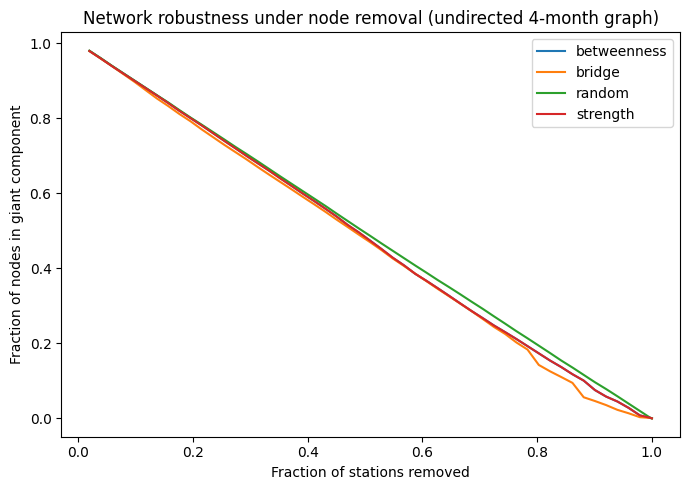

In [88]:
# --- Helper function: run one percolation experiment for a given node removal order ---
def percolation_curve(G_base, removal_order, step_nodes=50, compute_paths=False):
    """
    Run a percolation experiment on a graph by progressively removing nodes.
    G_base: the original undirected graph (we'll copy it inside).
    removal_order: list of nodes in the order they will be removed.
    step_nodes: record results every 'step_nodes' removals (to save time).
    compute_paths: if True, also compute average shortest path length in the giant component.
    """
    N = G_base.number_of_nodes()   # total number of nodes in the graph
    H = G_base.copy()              # work on a copy so the original graph stays intact
    removed = 0                    # counter for how many nodes have been removed
    records = []                   # list to store results at each step

    # remove nodes one by one following the given order
    for node in removal_order:
        if node not in H:          # skip if node already removed
            continue
        H.remove_node(node)        # remove the node from the graph
        removed += 1

        # only record results every 'step_nodes' removals, and at the very end
        if removed % step_nodes != 0 and removed != N:
            continue

        frac_removed = removed / N  # fraction of nodes removed so far

        # if the graph still has nodes and edges, compute giant component stats
        if H.number_of_nodes() > 0 and H.number_of_edges() > 0:
            comps = list(nx.connected_components(H))   # find all connected components
            giant_size = max(len(c) for c in comps)    # size of the largest component
            giant_frac = giant_size / N                # fraction of nodes in giant component

            avg_path = np.nan                          # default: not computed
            if compute_paths and giant_size > 1:       # optionally compute avg shortest path
                gcc_nodes = max(comps, key=len)        # nodes in the giant component
                GCC = H.subgraph(gcc_nodes).copy()     # subgraph of the giant component
                try:
                    avg_path = nx.average_shortest_path_length(GCC)
                except Exception:
                    avg_path = np.nan
        else:
            # if graph is empty, giant component size is zero
            giant_size = 0
            giant_frac = 0.0
            avg_path = np.nan

        # record the results for this step
        records.append({
            "removed": removed,
            "frac_removed": frac_removed,
            "giant_size": giant_size,
            "giant_frac": giant_frac,
            "avg_path_length": avg_path,
        })

        if removed == N:   # stop once all nodes are removed
            break

    # return results as a DataFrame
    return pd.DataFrame(records)


# --- Run percolation for each scenario defined earlier in `orders` ---
percolation_results = []   # list to collect results for each scenario

# aim for ~50 points on the curve by setting step size
step_nodes = max(1, G_und.number_of_nodes() // 50)

# run percolation for each removal strategy
for scenario, order in orders.items():
    curve = percolation_curve(G_und, order, step_nodes=step_nodes, compute_paths=False)
    curve["scenario"] = scenario   # tag results with scenario name
    percolation_results.append(curve)

# combine all scenario results into one DataFrame
df_percolation = pd.concat(percolation_results, ignore_index=True)

# quick check: print first few rows
print("Percolation results (head):")
print(df_percolation.head())


# --- Plot: fraction in giant component vs fraction removed ---
plt.figure(figsize=(7,5))
for scenario, df_curve in df_percolation.groupby("scenario"):
    plt.plot(df_curve["frac_removed"], df_curve["giant_frac"], label=scenario)

plt.xlabel("Fraction of stations removed")
plt.ylabel("Fraction of nodes in giant component")
plt.title("Network robustness under node removal (undirected 4-month graph)")
plt.legend()
plt.tight_layout()
plt.show()

### E.1 Percolation-style resilience curves — interpretation


**What the curves show.**

The figure *“Network robustness under node removal (undirected 4-month graph)”*
plots `giant_frac` versus `frac_removed` for four scenarios:

- **random** – stations removed uniformly at random,  
- **strength** – remove highest total-strength stations first,  
- **betweenness** – remove highest betweenness-centrality stations first,  
- **bridge** – remove “bridge-like” stations (cross-community / high betweenness).

Key observations:

- For most of the range (up to ~70–75% of stations removed), **all four curves
are almost on top of each other and roughly linear**.  
  - Even after removing ~50% of stations, **about half of all nodes are still
connected in the giant component**.  
  - This means the station network is **highly redundant**: many alternative
routes keep the giant component alive even when a large random subset of
stations fails.

- Differences appear only near the end of the process (when >80% of stations
are removed):  
  - Targeted removal by **betweenness** and **bridge** causes the giant component
to collapse **slightly earlier** than random.  
  - Strength-based removal is also a bit worse than random, but the gap is small.

- There is **no dramatic “early cliff”** for the targeted strategies.
To completely destroy global connectivity we still need to remove the vast
majority of stations in every scenario.

**Interpretation.**  
The Citi Bike station graph over this 4-month window behaves as a **robust,
redundant network** rather than a fragile hub-and-spoke system. Removing the
biggest hubs and bridges does hurt connectivity slightly more than random
failures, but the effect is modest:

- The network is **robust to both random outages and targeted attacks** on
individual high-centrality stations.  
- From a planning perspective, this suggests that **vulnerability is spread over
many stations**, not concentrated in a tiny set of “super-critical” nodes.


In [89]:
# --- Outcome E: Identify structurally critical stations from percolation scenarios ---

# 1. Collect the top-K removed nodes from each targeted scenario
targeted_scenarios = ["strength", "betweenness", "bridge"]   # focus only on targeted strategies
topK = 30   # number of nodes to take from the start of each removal order

rows = []
for scen in targeted_scenarios:
    order = orders[scen]   # get the removal order for this scenario
    for rank, node in enumerate(order[:topK], start=1):
        # record station ID, scenario name, and its rank position
        rows.append({
            "station_id": node,
            "scenario": scen,
            "rank_in_scenario": rank,
        })

# assemble into a DataFrame
df_crit_raw = pd.DataFrame(rows)


# 2. Compute the "best rank" for each station across all scenarios
best_rank = (
    df_crit_raw
    .groupby("station_id")["rank_in_scenario"].min()   # take the minimum rank across scenarios
    .rename("best_rank_across_scenarios")              # rename column for clarity
)

# merge back so each row knows the station’s best rank
df_crit = (
    df_crit_raw
    .merge(best_rank, on="station_id", how="left")
)


# 3. Join with centrality and community info from earlier sections

# ensure station_id is consistently stored as string across all DataFrames
df_crit["station_id"] = df_crit["station_id"].astype(str)
df_total_strength["station_id"] = df_total_strength["station_id"].astype(str)
df_betweenness["station_id"] = df_betweenness["station_id"].astype(str)
df_bridge["station_id"] = df_bridge["station_id"].astype(str)
df_communities["station_id"] = df_communities["station_id"].astype(str)

# collapse to one row per (station_id, scenario) and attach features from other tables
df_crit = (
    df_crit
    .drop_duplicates(subset=["station_id", "scenario", "rank_in_scenario"])
    .merge(
        df_total_strength[["station_id", "total_strength"]],
        on="station_id", how="left"
    )
    .merge(
        df_betweenness[["station_id", "betweenness"]],
        on="station_id", how="left"
    )
    .merge(
        df_bridge[["station_id", "cross_total"]],
        on="station_id", how="left"
    )
    .merge(
        df_communities[["station_id", "community_id", "community_size"]],
        on="station_id", how="left"
    )
)


# 4. Sort results to produce a clean short list of critical stations
df_crit_sorted = (
    df_crit
    .sort_values(["best_rank_across_scenarios", "scenario", "rank_in_scenario"])
    .reset_index(drop=True)
)

# display the top 25 rows of the critical station list
print("Critical stations from resilience experiments (head):")
print(df_crit_sorted.head(25))

Critical stations from resilience experiments (head):
   station_id     scenario  rank_in_scenario  best_rank_across_scenarios  \
0     6822.09  betweenness                 1                           1   
1     6140.05       bridge                 1                           1   
2     6140.05     strength                 1                           1   
3     6429.01  betweenness                 2                           2   
4     6450.05       bridge                 2                           2   
5     5905.14       bridge                19                           2   
6     5905.14     strength                 2                           2   
7     6450.05     strength                10                           2   
8     5329.03  betweenness                 3                           3   
9     6233.04  betweenness                10                           3   
10    6233.04       bridge                 3                           3   
11    5329.03       bridge        

### Outcome E – Structurally Critical Stations from Percolation Experiments


Outcome E reveals a small set of stations that are simultaneously high-load hubs, shortest-path conduits, and inter-community bridges. These nodes form the backbone of the Citi Bike network: closing them (due to maintenance, weather, or policy) would cause large-scale fragmentation, while reinforcing them (capacity, redundancy, backup stations) would greatly improve overall resilience.


## Outcome G: Dynamic and Temporal Network Patterns

**Goal.** Study how the Citi Bike station network changes over time – which hubs stay important, how communities evolve, and whether the system becomes more or less clustered – using time-sliced graphs.


In this notebook we implement a **monthly version** of that plan using the four-month dataset.  
The focus is on structural trends at the month level:

- **G.1 Global structural trends over months.**  
  - Use `df_monthly_stats` (built in Outcome A) to track:  
    - number of stations `nodes_N` and edges `edges_M`,  
    - edge density and average in-strength,  
    - reciprocity and small-world metrics (average shortest path in the GSCC, diameter),  
    - transitivity and average clustering coefficient.  
  - Plot each metric as a time series to see whether the network is growing, densifying, or becoming more/less small-world over the four months.

- **G.2 Hub stability and turnover.**  
  - For each month, take the top-K hubs from `monthly_hub_tables` (total strength / centrality from Outcome B).  
  - Compute **Jaccard overlap** between consecutive months’ top-K sets to measure hub stability.  
  - Classify stations by role over time (e.g., **persistent hubs** that stay in the top-K for many months vs **emerging hubs** that newly enter the top-K).  
  - Plot overlap curves and summarize hub roles to show how stable or volatile the core of the network is.

- **G.3 Community evolution over months.**  
  - Use `df_monthly_comm_stats` (from Outcome C) to examine, per month:  
    - number of detected communities,  
    - size of the largest and second-largest communities,  
    - fraction of nodes in the largest community,  
    - modularity of the partition.  
  - Plot these as time series to see whether the system is fragmenting into many small communities, dominated by one giant community, or maintaining a stable structure.
percolation experiments.




Months in monthly_hub_tables: ['2024-12', '2025-01', '2025-02', '2025-03', '2025-04']

Top hubs across months (head):
  station_id  total_strength    month
0    6756.01             6.0  2024-12
1    6474.11             6.0  2024-12
2    6700.01             6.0  2024-12
3    4166.08             5.0  2024-12
4    6626.01             5.0  2024-12

Jaccard overlap of top-20 hubs between consecutive months:
   month_1  month_2  intersection_size  union_size   jaccard
0  2024-12  2025-01                  1          39  0.025641
1  2025-01  2025-02                 14          26  0.538462
2  2025-02  2025-03                 12          28  0.428571
3  2025-03  2025-04                  5          35  0.142857


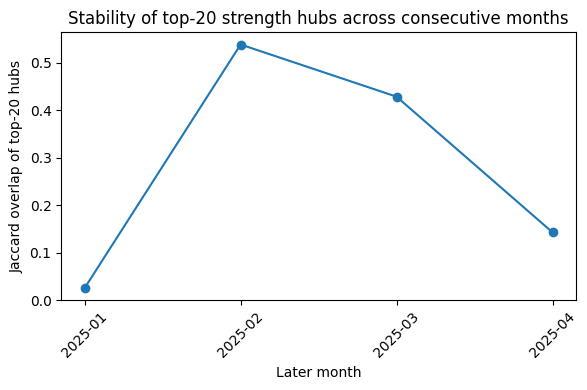


Hub roles (head):
   station_id  num_months_in_topK  total_strength  community_id  \
0     4166.08                   1             NaN             0   
1     4614.04                   1             NaN             0   
2     5187.03                   1             NaN             3   
3     5190.09                   1             NaN             1   
4     5276.04                   1             NaN             3   
5     5303.06                   3         19039.0             1   
6     5303.08                   1             NaN             1   
7     5329.03                   2         24930.0             1   
8     5374.01                   3         19475.0             1   
9     5492.05                   1             NaN             1   
10    5515.02                   1             NaN             1   
11    5561.06                   1             NaN             1   
12    5636.11                   1             NaN             1   
13    5712.03                   1          

In [90]:
# --- Outcome G: Hub Stability and Turnover Over Months ---

# Check that monthly hub tables are available
print("Months in monthly_hub_tables:", list(monthly_hub_tables.keys()))

# 1) Build top-K hub sets per month
topK = 20   # number of hubs to track per month

month_labels = sorted(monthly_hub_tables.keys())   # sort months chronologically
topK_sets = {}     # dictionary to store top-K hubs as sets
topK_lists = []    # list to collect top-K hubs with details

for m in month_labels:
    df_m = monthly_hub_tables[m]              # get hub table for this month
    df_m["station_id"] = df_m["station_id"].astype(str)   # ensure IDs are strings
    top_m = df_m.head(topK).copy()            # take the top-K rows
    topK_sets[m] = set(top_m["station_id"])   # store as a set for overlap calculations
    top_m["month"] = m                        # add month label
    topK_lists.append(top_m[["station_id", "total_strength", "month"]])  # keep relevant columns

# combine all months’ top hubs into one DataFrame
df_top_hubs_all = pd.concat(topK_lists, ignore_index=True)

print("\nTop hubs across months (head):")
print(df_top_hubs_all.head())


# 2) Jaccard overlap of top-K hubs between consecutive months
overlap_rows = []
for i in range(len(month_labels) - 1):
    m1 = month_labels[i]
    m2 = month_labels[i+1]
    s1 = topK_sets[m1]   # set of hubs in month 1
    s2 = topK_sets[m2]   # set of hubs in month 2
    inter = len(s1 & s2)   # intersection size
    union = len(s1 | s2)   # union size
    jaccard = inter / union if union > 0 else np.nan   # Jaccard similarity
    overlap_rows.append({
        "month_1": m1,
        "month_2": m2,
        "intersection_size": inter,
        "union_size": union,
        "jaccard": jaccard,
    })

# assemble into DataFrame
df_hub_overlap = pd.DataFrame(overlap_rows)

print("\nJaccard overlap of top-{} hubs between consecutive months:".format(topK))
print(df_hub_overlap)

# plot Jaccard overlap values across months
plt.figure(figsize=(6,4))
plt.plot(
    df_hub_overlap["month_2"],
    df_hub_overlap["jaccard"],
    marker="o"
)
plt.xlabel("Later month")
plt.ylabel("Jaccard overlap of top-{} hubs".format(topK))
plt.title("Stability of top-{} strength hubs across consecutive months".format(topK))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 3) Persistent vs emerging hubs

# count how many months each station appears in the top-K list
hub_counts = (
    df_top_hubs_all
    .groupby("station_id")["month"].nunique()
    .rename("num_months_in_topK")
    .reset_index()
)

# total number of months considered
num_months_total = len(month_labels)

# join with overall strength and community info
hub_counts["station_id"] = hub_counts["station_id"].astype(str)
df_total_strength["station_id"] = df_total_strength["station_id"].astype(str)
df_communities["station_id"] = df_communities["station_id"].astype(str)

df_hub_roles = (
    hub_counts
    .merge(df_total_strength[["station_id", "total_strength"]], on="station_id", how="left")
    .merge(df_communities[["station_id", "community_id", "community_size"]], on="station_id", how="left")
)

# define hub roles:
# - persistent if in top-K for nearly all months
# - emerging if only appears in the last month
persistent_threshold = max(1, num_months_total - 1)

df_hub_roles["role"] = "other"
df_hub_roles.loc[df_hub_roles["num_months_in_topK"] >= persistent_threshold, "role"] = "persistent_hub"

# mark emerging hubs (appear only in the last month)
last_month = month_labels[-1]
stations_last_month = topK_sets[last_month]
df_hub_roles.loc[
    (df_hub_roles["station_id"].isin(stations_last_month)) &
    (df_hub_roles["num_months_in_topK"] == 1),
    "role"
] = "emerging_hub"

print("\nHub roles (head):")
print(df_hub_roles.head(20))

print("\nExample persistent hubs:")
print(df_hub_roles[df_hub_roles["role"] == "persistent_hub"].head(10))

print("\nExample emerging hubs (only appear in the last month):")
print(df_hub_roles[df_hub_roles["role"] == "emerging_hub"].head(10))

### G.2 Hub stability and turnover of top-20 strength hubs

We track the **top-20 stations by strength (in+out trips)** for each month and
compare how similar those “hub lists” are across time.

---

#### 1) Jaccard overlap of top-20 hubs (stability over time)

The Jaccard index compares the sets of top-20 hubs in two consecutive months:

- **2024-12 → 2025-01: J ≈ 0.03 (1 common hub out of 39 distinct)**
  - Almost **no overlap**: the small December slice has a very different set of
    “top-20” stations compared to the fully active system in January.
  - This mainly reflects that **Dec 2024 is a tiny / partial month**, not a
    real stable regime.

- **2025-01 → 2025-02: J ≈ 0.54 (14 common hubs, 26 in union)**
  - Over half of the top-20 hubs are the **same stations** in both months.
  - Interpretation: once the system is fully running in winter, the **major
    hubs are quite stable**; the same busy stations keep dominating flows.

- **2025-02 → 2025-03: J ≈ 0.43 (12 common hubs, 28 in union)**
  - Still a **large stable core** of hubs, but with a bit more churn:
    a few stations drop out of the top-20 and a few new ones come in.
  - This is consistent with normal seasonal or demand shifts, not a
    structural break.

- **2025-03 → 2025-04: J ≈ 0.14 (5 common hubs, 35 in union)**
  - **Strong turnover**: only 5 stations remain in the top-20 from March to April.
  - Combined with earlier results (drop in density, strength, reciprocity),
    this suggests that **April has a very different demand pattern**:
    some previously dominant hubs lose volume, and new areas or corridors
    become relatively more important.

Overall:

- After December, the system enters a **stable “core hub” regime** in Jan–Mar:
  many of the same stations stay in the top-20.
- **April breaks that pattern**, with a large reconfiguration of where the
  highest flows are concentrated.

---

#### 2) Persistent vs emerging hubs

We label hubs based on how many months they appear in the top-20:

- **Persistent hubs**: stations that appear in the top-20 in at least  
  `num_months_total − 1` months (here, ≥4 out of 5 months).
- **Emerging hubs**: stations that **only appear in the last month (2025-04)**  
  and appear in the top-20 exactly once.

From the `df_hub_roles` table:

- There is **one clear persistent hub**, station **5905.14**:
  - Appears in the top-20 hubs in **4 months**.
  - Has very high overall total strength (~26k trips) and lives in
    **community 1**, which is one of the large communities (size 279).
  - Interpretation: this is a **super-core hub** that consistently handles
    high volumes and anchors its community over the entire 4-month period.

- Several **emerging hubs** (e.g., 5303.08, 5561.06, 5636.11, 5712.03, 5880.02,
  5989.02, 6306.06, 6459.04, 6676.02, 6839.15):
  - Each appears in the top-20 **only in April**.
  - Many belong to the largest communities (community 1 with 279 nodes,
    community 4 with 339 nodes).
  - Interpretation: in April the demand within these big communities
    **shifts toward new stations**, which suddenly become top-20 by strength.
    These may reflect new local hotspots (e.g., seasonal destinations,
    changed commuting patterns, or events).

- Other stations are labelled **“other”**:
  - They appear in the top-20 in some months but not often enough to be
    persistent, and not exclusively in the last month, so they represent
    **medium-term hubs with occasional prominence**.

**High-level story:**

- The Citi Bike system has at least **one long-term “anchor” hub** that is
  central throughout the whole period.
- **Most of the other top-20 hubs are more volatile**, with significant
  turnover, especially in April.
- April shows **emerging hubs concentrated in the largest communities**, which
  matches the aggregate patterns: overall traffic and reciprocity drop, but the
  network reorganises around a different set of high-volume stations.


Monthly structural stats:


,nodes_N,edges_M,density,avg_in_degree,avg_out_degree,avg_in_strength,avg_out_strength,reciprocity,num_WCC,giant_WCC_size,num_SCC,giant_SCC_size,avg_shortest_path_GSCC,diameter_GSCC,transitivity,avg_clustering
month,,,,,,,,,,,,,,,,
2024-12,249,151,0.002445,0.606426,0.606426,0.662651,0.662651,0.000000,99,12,249,1,NaN,NaN,0.038961,0.002410
2025-01,2191,272216,0.056732,124.242812,124.242812,448.260612,448.260612,0.587460,1,2191,49,2143,2.441468,6.0,0.460912,0.394233
2025-02,2203,274980,0.056685,124.820699,124.820699,446.710395,446.710395,0.588610,2,2201,58,2146,2.444982,6.0,0.470263,0.392694
2025-03,2254,279960,0.055129,124.205856,124.205856,436.755102,436.755102,0.486584,1,2254,173,2082,2.420003,6.0,0.459089,0.402327
2025-04,2256,211712,0.041616,93.843972,93.843972,313.446365,313.446365,0.337364,1,2256,508,1749,2.484680,6.0,0.412150,0.395445


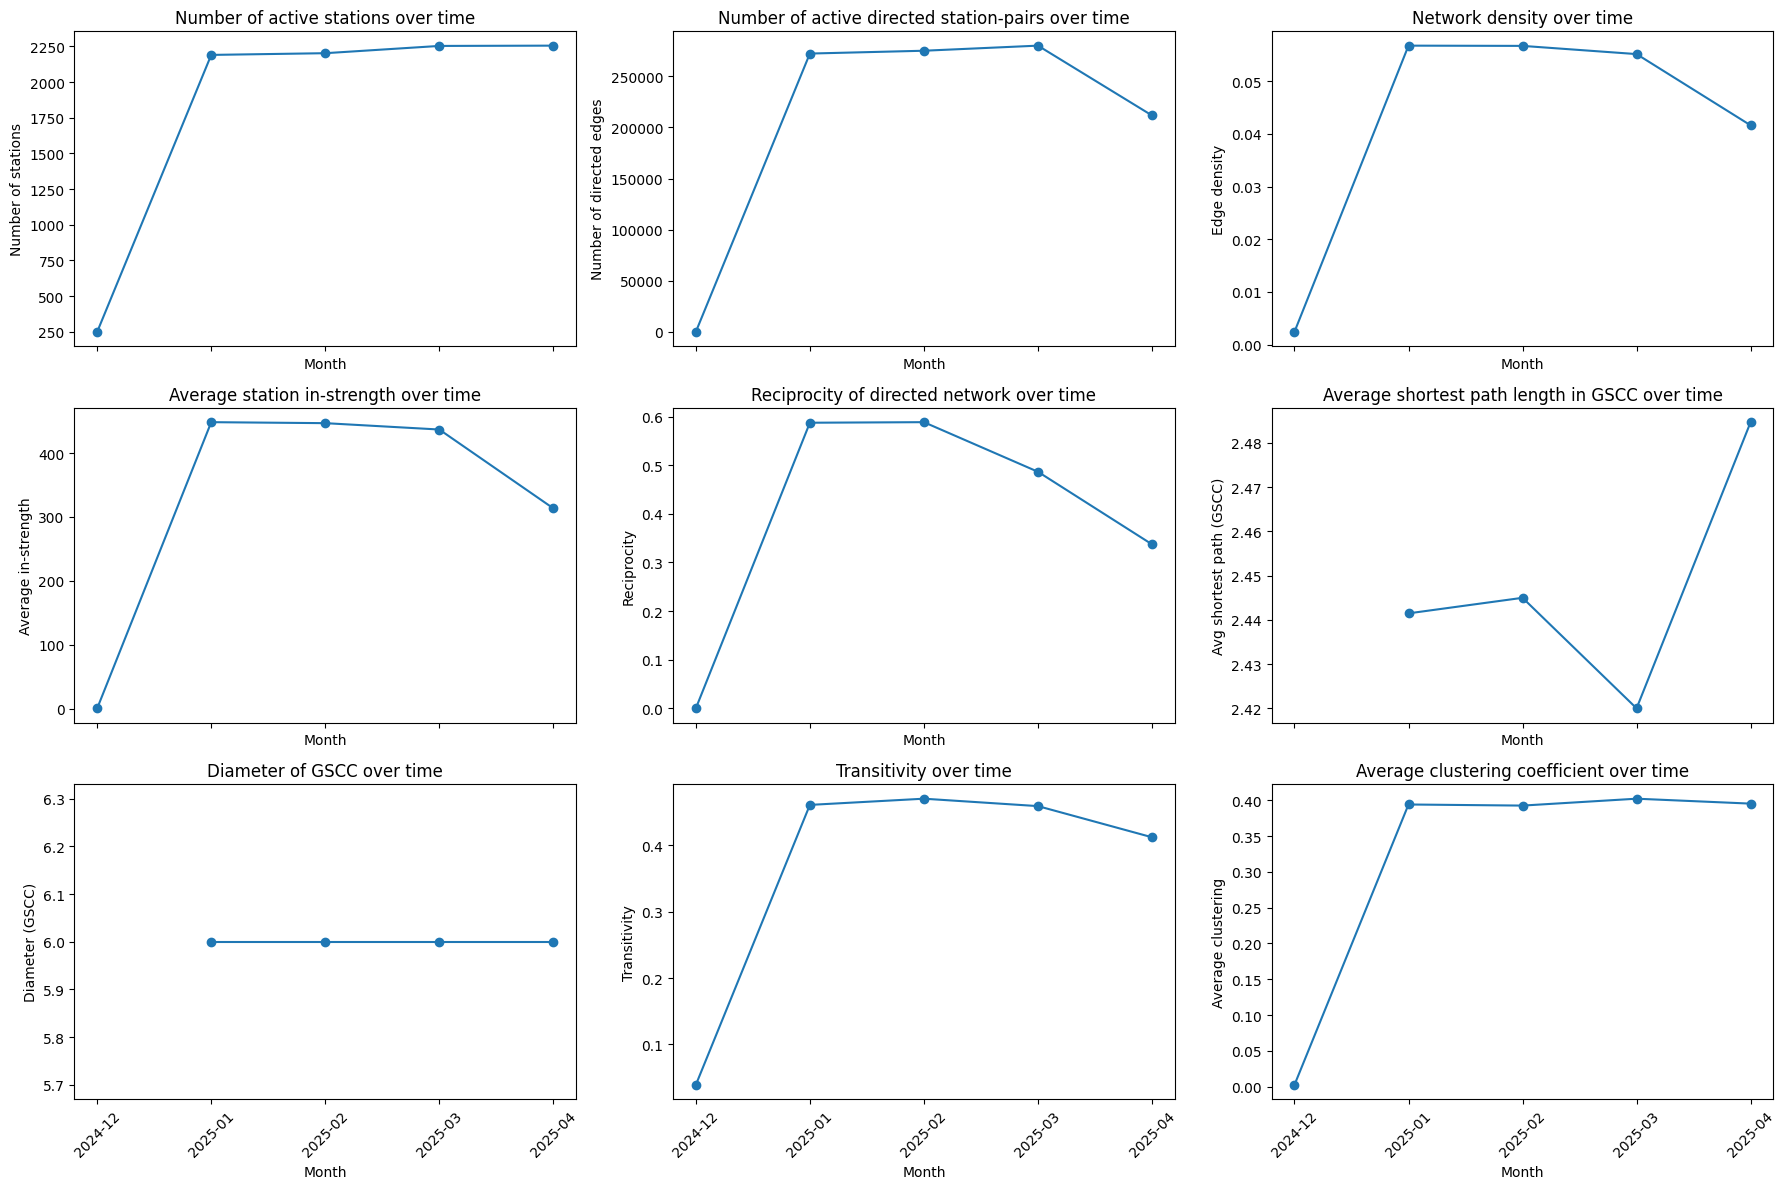

In [91]:
# --- Outcome: Monthly structural statistics plots ---

# Check that the monthly stats DataFrame exists
print("Monthly structural stats:")
display(df_monthly_stats)

# Define which columns to plot, along with labels and titles
plot_specs = [
    ("nodes_N",                "Number of stations",                  "Number of active stations over time"),
    ("edges_M",                "Number of directed edges",            "Number of active directed station-pairs over time"),
    ("density",                "Edge density",                        "Network density over time"),
    ("avg_in_strength",        "Average in-strength",                 "Average station in-strength over time"),
    ("reciprocity",            "Reciprocity",                         "Reciprocity of directed network over time"),
    ("avg_shortest_path_GSCC", "Avg shortest path (GSCC)",            "Average shortest path length in GSCC over time"),
    ("diameter_GSCC",          "Diameter (GSCC)",                     "Diameter of GSCC over time"),
    ("transitivity",           "Transitivity",                        "Transitivity over time"),
    ("avg_clustering",         "Average clustering",                  "Average clustering coefficient over time"),
]

# Create one big figure with 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
axes = axes.ravel()  # flatten 3x3 grid into a 1D list for easy looping

# Loop through each subplot specification and plot the corresponding column
for ax, (col, ylabel, title) in zip(axes, plot_specs):
    ax.plot(df_monthly_stats.index, df_monthly_stats[col], marker="o")  # plot values with markers
    ax.set_title(title)                                                # set subplot title
    ax.set_xlabel("Month")                                             # x-axis label
    ax.set_ylabel(ylabel)                                              # y-axis label
    ax.tick_params(axis="x", rotation=45)                              # rotate month labels for readability

# If there were fewer than 9 plots, we could delete extra axes; here it's exactly 9 so no need.
# for j in range(len(plot_specs), len(axes)):
#     fig.delaxes(axes[j])

# Adjust layout to avoid overlaps and show the figure
fig.tight_layout()
plt.show()

### Interpretation – Monthly Community Evolution

From December 2024 through April 2025, we see how the meso-scale community structure of the Citi Bike network evolves over time.

**1. December 2024 is an outlier (highly fragmented network)**  

- `num_communities = 99` with a largest community of only 12 stations and a second-largest community of 7.
- Modularity is extremely high (`Q ≈ 0.98`), meaning communities are almost completely disconnected from each other.
- Only 249 stations are present and the largest community holds about 4.8% of them.

Interpretation: in December, the network behaves like many tiny components or weakly connected clusters (likely very sparse usage or partial coverage). The community algorithm effectively treats each small component as its own community.

---

**2. From January 2025 onward, the network stabilizes into a few large blocks**

For 2025-01 to 2025-04:

- `num_communities` is between 7 and 9, so the network consolidates into a small set of well-defined modules instead of many tiny fragments.
- The largest community is consistently around 460–530 stations  
  (`largest_comm_frac ≈ 0.20–0.23` of all stations).
- The second-largest community is almost as big, around 388–514 stations  
  (`second_largest_comm_frac ≈ 0.17–0.23`).

Together, the top two communities always contain roughly 40–45% of all stations, and the remaining 5–7 communities share the other 55–60%.

Interpretation: after December, the system settles into a stable “two-mega-community plus several medium communities” structure. We do not see communities appearing and disappearing; instead, the same basic blocks persist while their sizes adjust slightly month to month.

---

**3. Modularity slowly decreases over time**

- January: `Q ≈ 0.579`  
- February: `Q ≈ 0.562`  
- March: `Q ≈ 0.541`  
- April: `Q ≈ 0.515`

Interpretation: community structure remains strong (Q > 0.5), but the gradual decline suggests increasing cross-community travel. As we move from winter into spring, riders take more trips that connect different parts of the city, slightly blurring the boundaries between communities.

---

**Summary for Outcome G**

- December 2024 shows a highly fragmented, low-usage network with many tiny communities.  
- Starting in January 2025, the system exhibits a stable multi-community backbone, dominated by two large communities of comparable size plus several smaller ones.  
- Over the spring, modularity gently declines, indicating that while the core community structure persists, mobility between communities increases, consistent with more cross-neighborhood riding as the season progresses.


In [92]:
# --- Integrated node summary for Outcomes E + G ---
# (Which stations are critical, persistent hubs, emerging hubs, etc.)

# 1) Ensure station IDs are stored as strings in both DataFrames
df_crit_sorted["station_id"] = df_crit_sorted["station_id"].astype(str)
df_hub_roles["station_id"] = df_hub_roles["station_id"].astype(str)

# 2) Collapse critical info per station:
#    - best rank across scenarios
#    - list of scenarios where the station is considered critical
crit_station_tags = (
    df_crit_sorted
    .groupby("station_id")
    .agg(
        best_rank_across_scenarios=("best_rank_across_scenarios", "min"),
        critical_scenarios=("scenario", lambda x: ",".join(sorted(set(x))))
    )
    .reset_index()
)
crit_station_tags["is_critical"] = True   # mark these stations as critical

# Aggregate numeric features from the critical side (take max across scenarios for each station)
crit_features = (
    df_crit_sorted
    .groupby("station_id")
    .agg(
        total_strength=("total_strength", "max"),
        betweenness=("betweenness", "max"),
        cross_total=("cross_total", "max"),
        community_id=("community_id", "first"),
        community_size=("community_size", "first"),
    )
    .reset_index()
)

# Merge tags and features into one critical nodes DataFrame
df_crit_nodes = crit_station_tags.merge(crit_features, on="station_id", how="left")

# 3) Bring in hub roles from Outcome G (persistent/emerging/other)
df_hub_roles_small = df_hub_roles[["station_id", "num_months_in_topK", "role"]].copy()
df_hub_roles_small["is_hub"] = True   # mark these stations as hubs

# 4) Outer-join critical info and hub info so we capture all stations
df_node_summary = df_crit_nodes.merge(df_hub_roles_small, on="station_id", how="outer")

# Fill missing flags for non-critical / non-hub stations
df_node_summary["is_critical"] = df_node_summary["is_critical"].fillna(False)
df_node_summary["is_hub"] = df_node_summary["is_hub"].fillna(False)

# 5) Define a combined classification label for each station
def classify(row):
    if row["is_critical"] and row["role"] == "persistent_hub":
        return "critical & persistent"
    if row["is_critical"] and row["role"] == "emerging_hub":
        return "critical & emerging"
    if row["is_critical"]:
        return "critical_only"
    if row["role"] == "persistent_hub":
        return "persistent_only"
    if row["role"] == "emerging_hub":
        return "emerging_only"
    return "other"

df_node_summary["combined_role"] = df_node_summary.apply(classify, axis=1)

# 6) Sort by importance:
#    - critical stations first
#    - then by best rank (ascending, so smaller rank = more important)
#    - then by number of months as hub (descending)
df_node_summary_sorted = df_node_summary.sort_values(
    ["is_critical", "best_rank_across_scenarios", "num_months_in_topK"],
    ascending=[False, True, False]
)

# Display the top 30 rows of the integrated summary
print("Integrated node summary (top 30 rows):")
display(df_node_summary_sorted.head(30))

Integrated node summary (top 30 rows):


C:\Users\krant\AppData\Local\Temp\ipykernel_30576\2298800688.py:47: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\krant\AppData\Local\Temp\ipykernel_30576\2298800688.py:48: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,station_id,best_rank_across_scenarios,critical_scenarios,is_critical,total_strength,betweenness,cross_total,community_id,community_size,num_months_in_topK,role,is_hub,combined_role
47,6140.05,1.0,"bridge,strength",True,29703.0,NaN,11495.0,1.0,279.0,3.0,other,True,critical_only
86,6822.09,1.0,betweenness,True,NaN,0.200759,4000.0,4.0,339.0,2.0,other,True,critical_only
35,5905.14,2.0,"bridge,strength",True,26478.0,NaN,6226.0,1.0,279.0,4.0,persistent_hub,True,critical & persistent
68,6450.05,2.0,"bridge,strength",True,21347.0,NaN,9612.0,4.0,339.0,2.0,other,True,critical_only
67,6429.01,2.0,betweenness,True,NaN,0.167171,2785.0,6.0,399.0,NaN,NaN,False,critical_only
84,6726.01,3.0,"bridge,strength",True,25145.0,NaN,6006.0,4.0,339.0,3.0,other,True,critical_only
21,5329.03,3.0,"betweenness,bridge,strength",True,24930.0,0.133092,7574.0,1.0,279.0,2.0,other,True,critical_only
55,6233.04,3.0,"betweenness,bridge,strength",True,23007.0,0.076249,9018.0,1.0,279.0,2.0,other,True,critical_only
49,6173.08,4.0,bridge,True,NaN,NaN,8778.0,4.0,339.0,2.0,other,True,critical_only
48,6170.02,4.0,betweenness,True,NaN,0.131688,3337.0,6.0,399.0,NaN,NaN,False,critical_only


In [96]:


# --- 1. Prepare station positions (lat / lon) ---

# station_comm must have: station_id, station_name, lat, lng, community_id
pos_dict = (
    station_comm
    .set_index("station_id")[["lat", "lng", "station_name", "community_id"]]
    .to_dict("index")
)

print("Stations with coordinates in pos_dict:", len(pos_dict))

# --- 2. Pick top-K OD edges to draw (to avoid 500k lines) ---

K_geo = 2000  # tweak: 500 / 1000 / 2000 depending on performance

edges_geo = (
    edges_all
    .sort_values("w", ascending=False)
    .head(K_geo)
    .reset_index(drop=True)
)

print("Top-K edges used for map:", len(edges_geo))

# --- 3. Build edge line segments in lat/lon ---
# Split into:
#   - intra-community edges  (same community on both ends)
#   - cross-community edges  (different communities / unknown)

edge_lat_intra, edge_lon_intra = [], []
edge_lat_cross, edge_lon_cross = [], []

for _, row in edges_geo.iterrows():
    u = row["start_station_id"]
    v = row["end_station_id"]
    if (u not in pos_dict) or (v not in pos_dict):
        continue

    info_u = pos_dict[u]
    info_v = pos_dict[v]

    lat_u, lon_u = info_u["lat"], info_u["lng"]
    lat_v, lon_v = info_v["lat"], info_v["lng"]
    comm_u, comm_v = info_u["community_id"], info_v["community_id"]

    # Decide if this is within-community or cross-community
    if (comm_u is not None) and (comm_v is not None) and (comm_u == comm_v):
        edge_lat_intra += [lat_u, lat_v, None]
        edge_lon_intra += [lon_u, lon_v, None]
    else:
        edge_lat_cross += [lat_u, lat_v, None]
        edge_lon_cross += [lon_u, lon_v, None]

edge_trace_intra = go.Scattermapbox(
    lat=edge_lat_intra,
    lon=edge_lon_intra,
    mode="lines",
    line=dict(width=1, color="rgba(80,80,80,0.18)"),
    hoverinfo="none",
    name="Within-community flows"
)

edge_trace_cross = go.Scattermapbox(
    lat=edge_lat_cross,
    lon=edge_lon_cross,
    mode="lines",
    line=dict(width=2, color="rgba(200,0,0,0.35)"),
    hoverinfo="none",
    name="Cross-community flows"
)

# --- 4. Node markers: stations (size by strength, color by community) ---

# Fallback if total_strength not in scope (should be from Outcome B)
if "total_strength" not in globals():
    total_strength = {
        n: in_str_all.get(n, 0) + out_str_all.get(n, 0)
        for n in G_all.nodes()
    }

# Only show nodes that appear in the top-K edges (keeps plot light)
nodes_used = sorted(
    set(edges_geo["start_station_id"]).union(set(edges_geo["end_station_id"]))
)

# Precompute max strength for scaling sizes
max_strength = max(total_strength.get(n, 0.0) for n in nodes_used) or 1.0

# Choose top hubs to highlight separately (by total strength)
K_hubs = 20
top_hubs = sorted(
    [(n, total_strength.get(n, 0.0)) for n in nodes_used],
    key=lambda x: x[1],
    reverse=True
)[:K_hubs]
hub_id_set = {n for n, _ in top_hubs}

node_lat, node_lon, node_text, node_color, node_size = [], [], [], [], []
hub_lat, hub_lon, hub_text, hub_size = [], [], [], []

for n in nodes_used:
    if n not in pos_dict:
        continue
    info = pos_dict[n]
    lat, lon = info["lat"], info["lng"]
    name = info["station_name"]
    comm = info["community_id"]

    strength = float(total_strength.get(n, 0.0))
    size_val = 5 + 15 * (strength / max_strength)  # base marker size
    text_val = (
        f"Station: {name}<br>"
        f"ID: {n}<br>"
        f"Total strength: {strength:.0f}<br>"
        f"Community: {comm}"
    )

    if n in hub_id_set:
        # Highlight hubs in a separate trace
        hub_lat.append(lat)
        hub_lon.append(lon)
        hub_text.append("HUB<br>" + text_val)
        hub_size.append(size_val * 1.3)
    else:
        node_lat.append(lat)
        node_lon.append(lon)
        node_color.append(comm if comm is not None else -1)
        node_size.append(size_val)
        node_text.append(text_val)

node_trace = go.Scattermapbox(
    lat=node_lat,
    lon=node_lon,
    mode="markers",
    marker=dict(
        size=node_size,
        color=node_color,
        colorscale="Viridis",
        opacity=0.8,
        showscale=True,
        colorbar=dict(title="Community ID")
    ),
    text=node_text,
    hoverinfo="text",
    name="Stations"
)

hub_trace = go.Scattermapbox(
    lat=hub_lat,
    lon=hub_lon,
    mode="markers",
    marker=dict(
        size=hub_size,
        color="red",
        opacity=0.95,
        symbol="circle",
    ),
    text=hub_text,
    hoverinfo="text",
    name=f"Top {K_hubs} hubs"
)


# --- 5. Figure layout: NYC basemap with OpenStreetMap tiles ---

center_lat = station_comm["lat"].mean()
center_lon = station_comm["lng"].mean()

fig_geo = go.Figure(
    data=[edge_trace_intra, edge_trace_cross, node_trace, hub_trace],
    layout=go.Layout(
        title=f"NYC Citi Bike Network on Map (top {K_geo} OD flows)",
        showlegend=True,
        margin=dict(l=0, r=0, t=40, b=0),
        mapbox=dict(
            style="open-street-map",   # no Mapbox token needed
            center=dict(lat=center_lat, lon=center_lon),
            zoom=11
        )
    )
)

fig_geo.show()


Stations with coordinates in pos_dict: 2298
Top-K edges used for map: 2000


C:\Users\krant\AppData\Local\Temp\ipykernel_30576\2906606278.py:54: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\krant\AppData\Local\Temp\ipykernel_30576\2906606278.py:63: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\krant\AppData\Local\Temp\ipykernel_30576\2906606278.py:131: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\krant\AppData\Local\Temp\ipykernel_30576\2906606278.py:148: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### Interpretation – Citi Bike Network on NYC Map (Communities, Hubs, and Flows)

This figure overlays the **aggregated Citi Bike network** on a geographic map of NYC, combining information from several earlier outcomes:

- Node positions come from the station coordinates table (`station_comm`).
- Node colors are **community IDs** from Outcome C.
- Node sizes are **total strength** (in + out flow) from Outcome B.
- Edges are the **top K origin–destination flows** (`edges_all`, sorted by weight `w`).

**What the map is showing**

1. **Within-community vs. cross-community flows**

   - Thin grey lines: **intra-community edges**, where start and end stations belong to the same community.  
     These show the dense internal circulation inside each community.
   - Thicker red lines: **cross-community edges**, where the trip connects two different communities  
     (or where a community label is missing).  
     These highlight **bridges between communities** and the main inter-neighborhood corridors.

   Visual use: clusters of grey links mark cohesive local “neighborhood cycling basins,” while red links reveal where riders regularly move between them (e.g., across rivers or between business districts and residential areas).

2. **Stations (all nodes used in top-K edges)**

   - Each dot is a station that appears in at least one of the top `K_geo` OD flows.
   - **Color** = community ID. Stations with the same color form spatial clusters that correspond to the communities previously found with Louvain.
   - **Size** = total strength of the station (sum of incoming + outgoing trip weights), rescaled between a base size and a maximum.

   Visual use: large colored nodes inside a community show its internal hubs; smaller nodes represent minor local stations.

3. **Top hubs (highlighted)**

   - The top `K_hubs` stations by total strength are plotted in a separate red marker layer.
   - These markers are slightly larger than normal and have a tooltip starting with “HUB”.
   - Hover text for each hub includes:
     - Station name and ID
     - Total strength (trip volume)
     - Community ID

   Visual use: these are the **key interchange stations** for the system. They often sit:
   - In the densest parts of each community, or
   - On the boundary between communities, close to major cross-community edges.

**How to read the figure in the report**

- Areas where many large nodes of the same color cluster together correspond to **strong internal communities** (Outcome C).
- Places where many red edges depart from or arrive at a small set of hubs indicate **spatial bottlenecks and gateways** between communities.
- Comparing node size and edge density helps explain why some stations were identified as structurally critical in Outcome E (percolation experiments).

**Where this figure belongs**

This map is best positioned as part of **Outcome C (Community structure and spatial layout)**, with a cross-reference to **Outcome B**:

- Outcome B provides the **strength / hub** information used for node sizing and hub selection.
- Outcome C provides the **community labels** used for node colors and the distinction between intra- vs. cross-community flows.

In the written report you can introduce it as:

> “To put the community structure and hub statistics in geographic context, Figure X plots the top origin–destination flows on the NYC map, coloring stations by community and highlighting the top hubs by total flow.”


### Integrated node summary (Outcomes E + G)

This table combines:

- **Outcome E (percolation / node removal):**  
  How quickly the giant component collapses when we remove stations in different
  orders (betweenness, bridge, strength, random).
- **Outcome G (hub stability):**  
  How often a station appears among the **top-20 strength hubs** across months
  and whether it is persistent or emerging.

Each row is one station with:

- `best_rank_across_scenarios`: **1 = most critical** in at least one removal
  scenario, larger = less critical.
- `critical_scenarios`: which removal strategies flagged it as highly critical.
- `total_strength`: max monthly total trips (in+out) observed.
- `cross_total`: max monthly *inter-community* trips (bridge traffic).
- `community_id`, `community_size`: which Louvain community it belongs to and
  how large that community is.
- `num_months_in_topK`, `role`: how many months it was in the top-20 hubs, and
  whether it is a `persistent_hub`, `emerging_hub`, or `other`.
- `combined_role`: final label combining “critical” (Outcome E) and “hub type”
  (Outcome G).

---

### 1. The single **“critical & persistent”** super-hub

- **Station 5905.14**  
  - `best_rank_across_scenarios = 2`  
    → It is **near the very top** of all critical stations; removing it early
      in percolation quickly shrinks the giant component.
  - `critical_scenarios = bridge,strength`  
    → It is crucial both as a **heavy-traffic node** and as a **bridge** in the
      community structure.
  - `total_strength ≈ 26k`, `cross_total ≈ 6.2k`  
    → Very high traffic overall, with substantial trips that **cross community
      boundaries**.
  - `community_id = 1`, `community_size = 279`  
    → Sits in one of the large communities and helps hold it together.
  - `num_months_in_topK = 4`, `role = persistent_hub`  
    → Appears in the top-20 strength list in **4 out of 5 months**.
  - `combined_role = critical & persistent`  

**Interpretation:**  
Station 5905.14 is your **core backbone station**:  
it is structurally critical *and* a long-term strength hub.  
Removing it both fractures connectivity and eliminates a major flow
concentrator.

---

### 2. **Critical but not persistent** hubs (“critical_only”)

Most of the top rows (e.g., 6140.05, 6822.09, 6450.05, 6726.01, 5329.03, 6233.04,
5788.13, 5779.11, 6098.10, 7059.08, 6492.08, …) have:

- `is_critical = True`, often with **very good ranks** (1st–10th),
- but `role = other` (or occasionally `NaN`) and `combined_role = critical_only`.

Typical pattern:

- **High `cross_total` and large community_size**  
  → They carry a lot of inter-community traffic, especially in communities 1
    (`size = 279`) and 4 (`size = 339`).
- They may enter the top-20 list in **1–3 months**, but not enough to be
  labelled persistent.

**Interpretation:**

- These stations are **structurally dangerous weak points**:
  if we remove them, the network’s giant component shrinks quickly,
  even though they are **not always the very biggest hubs in every month**.
- They often behave like **bridges between large communities**:
  their importance comes from **where** they sit rather than how extreme
  their raw traffic is.
- For planning, they are **hidden vulnerabilities**: they might not look like
  the top station by usage charts, but failure here would severely fragment
  the system.

Example:

- **Station 6140.05** (`best_rank = 1`, `bridge,strength`, `cross_total ≈ 11.5k`,
  `num_months_in_topK = 3`)  
  → A **top-ranked critical bridge + strength node** in community 1, with
    substantial cross-community traffic, but not quite persistent enough to
    be labelled a long-term hub.

---

### 3. **Critical & emerging** hubs

- **Station 6459.04**
  - `best_rank_across_scenarios = 6`, `critical_scenarios = bridge`  
    → High in the criticality ranking, mainly due to its **bridge role**.
  - `community_id = 4`, `community_size = 339`  
    → In one of the biggest communities.
  - `num_months_in_topK = 1`, `role = emerging_hub`  
    → Appears as a top-20 strength hub **only in the last month (April)**.
  - `combined_role = critical & emerging`.

**Interpretation:**  
6459.04 is a **newly emerging, but already structurally critical** hub:  
in April, flows concentrate on this station, and percolation analysis says
removing it would significantly damage connectivity.  
If trends continue, this node could become as important as the long-term
backbone hubs and should be watched closely (capacity, reliability, etc.).

---

### 4. Hubs that are **important for strength** but less so for structure

Some stations (e.g., 5788.13, 5779.11, 6233.04, 6098.10, 6197.08, 6492.08,
6602.03) have:

- high `total_strength`,
- moderate `best_rank_across_scenarios` (5–14),
- role = `other` and `combined_role = critical_only`,
- appear in the top-20 in **2–3 months**.

**Interpretation:**

- These stations are **busy and often high-volume**, so they matter for daily
  operations.
- Structurally, however, they behave more like **redundant hubs** inside large
  communities: they are important, but the network can route around them more
  easily than around the very top bridge nodes.

---

### 5. Nodes with betweenness-driven criticality

Stations like 6822.09, 6429.01, 6170.02, 5944.01, 6089.07, 7020.02, 7682.01,
5348.02, 4710.06, etc. have:

- `critical_scenarios` containing **betweenness**,
- relatively high betweenness values (e.g. 0.20, 0.17, 0.13, …),
- often `num_months_in_topK = NaN` (never in top-20 by strength).

**Interpretation:**

- These are **pure “routing” bottlenecks**:
  - They may not carry the largest volumes overall,
  - but many shortest paths go through them.
- Removing them in a betweenness-based attack **quickly lengthens routes and
  breaks global connectivity**, even though they might look only “medium-busy”
  in raw usage statistics.

---

### 6. Overall story

- You have **three kinds of important stations**:

  1. **Critical & persistent (e.g., 5905.14):**  
     Long-term super-hubs that are structurally central *and* consistently
     high-volume. These are your **top priority for resilience planning**.

  2. **Critical_only (many entries):**  
     Bridges and structural bottlenecks that **might not always be the very
     busiest stations**, but whose removal rapidly fragments the network.  
     These are **hidden vulnerabilities** and good candidates for building
     redundancy (alternative routes, nearby stations, etc.).

  3. **Critical & emerging (e.g., 6459.04):**  
     Newly active hubs that are already structurally important.  
     They signal **shifting demand** and **new weak points** as the system
     evolves (notably in April).

- Most of these critical nodes sit in the **largest communities (1 and 4)**,
  confirming that the **core of the network’s community structure is also where
  most structural risk is concentrated**.

In short, this table lets you move from “which nodes are important?” to a
more nuanced picture:  
**which stations are long-term backbone hubs, which are hidden structural
bridges, and which are newly emerging hotspots that the operator should
monitor or reinforce.**


In [94]:
# --- Build a unique station → (name, lat, lng) table ---

# From start stations: select relevant columns, drop rows with missing IDs/coordinates,
# remove duplicates, and rename columns to a consistent format
station_pos_start = (
    df_all[["start_station_id", "start_station_name", "start_lat", "start_lng"]]
    .dropna(subset=["start_station_id", "start_lat", "start_lng"])
    .drop_duplicates(subset=["start_station_id"])
    .rename(columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng",
    })
)

# From end stations: same process as above, but using end station columns
station_pos_end = (
    df_all[["end_station_id", "end_station_name", "end_lat", "end_lng"]]
    .dropna(subset=["end_station_id", "end_lat", "end_lng"])
    .drop_duplicates(subset=["end_station_id"])
    .rename(columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng",
    })
)

# Combine start and end station tables, then drop duplicates by station_id
station_pos = pd.concat([station_pos_start, station_pos_end], ignore_index=True)
station_pos = station_pos.drop_duplicates(subset=["station_id"])

print("Station positions table:", station_pos.shape)
print(station_pos.head())


# --- Attach community_id from df_communities (built earlier in Outcome C) ---
station_comm = (
    station_pos
    .merge(
        df_communities[["station_id", "community_id"]],
        on="station_id",
        how="left"
    )
)

print("station_comm shape:", station_comm.shape)
print(station_comm.head())

Station positions table: (2298, 4)
  station_id             station_name        lat        lng
0    6182.02          W 20 St & 7 Ave  40.742388 -73.997262
1    5238.05  St James Pl & Oliver St  40.713079 -73.998512
2    6197.08          E 33 St & 1 Ave  40.743227 -73.974498
3    6659.09    Madison Ave & E 51 St  40.758630 -73.975130
4    5379.10     N 6 St & Bedford Ave  40.717452 -73.958509
station_comm shape: (2298, 5)
  station_id             station_name        lat        lng  community_id
0    6182.02          W 20 St & 7 Ave  40.742388 -73.997262             1
1    5238.05  St James Pl & Oliver St  40.713079 -73.998512             1
2    6197.08          E 33 St & 1 Ave  40.743227 -73.974498             4
3    6659.09    Madison Ave & E 51 St  40.758630 -73.975130             4
4    5379.10     N 6 St & Bedford Ave  40.717452 -73.958509             3


### Interpretation – Station Position and Community Table

This cell constructs a clean table of **unique Citi Bike stations** with their
geographic coordinates and community assignments.

**1. Building the station position table**

- We first extract station information separately from:
  - the **start** columns (`start_station_id`, `start_station_name`, `start_lat`, `start_lng`),
  - the **end** columns (`end_station_id`, `end_station_name`, `end_lat`, `end_lng`).
- For each side we:
  - drop rows where `station_id` or coordinates are missing,
  - keep only one row per `station_id`,
  - rename columns into a common schema:  
    `station_id`, `station_name`, `lat`, `lng`.
- Then we concatenate start and end tables and de-duplicate again on `station_id`.

Result:

- `station_pos` has **2,298 unique stations**, each with a name and lat/lon:
  - Example: `6182.02` = “W 20 St & 7 Ave” at (40.742388, −73.997262).

This table is the master reference for mapping stations on any geographic plot.

---

**2. Attaching community labels**

- We merge `station_pos` with `df_communities[["station_id", "community_id"]]`
  (computed in Outcome C) using a left join on `station_id`.

Result:

- `station_comm` has shape `(2298, 5)` and columns:  
  `station_id`, `station_name`, `lat`, `lng`, `community_id`.
- Every station now has:
  - its **location** (lat/lng),
  - its **community_id**, indicating which Louvain community it belongs to.

Example rows:

- `6182.02` (“W 20 St & 7 Ave”) → community 1  
- `5238.05` (“St James Pl & Oliver St”) → community 1  
- `6197.08` (“E 33 St & 1 Ave”) → community 4  
- `6659.09` (“Madison Ave & E 51 St”) → community 4  
- `5379.10` (“N 6 St & Bedford Ave”) → community 3  

---

**How this will be used**

The `station_comm` table is the key input for:

- plotting **community-colored maps** of stations,
- summarizing **spatial footprints** of each community,
- linking node-level metrics (strength, betweenness, bridge score) to real
  locations on the city map.


In [95]:
# --- 1. Prepare station positions (lat / lon) ---
# Build a dictionary keyed by station_id with lat, lon, name, and community info
pos_dict = (
    station_comm
    .set_index("station_id")[["lat", "lng", "station_name", "community_id"]]
    .to_dict("index")
)

print("Stations with coordinates in pos_dict:", len(pos_dict))


# --- 2. Pick top-K OD edges to draw (to avoid plotting hundreds of thousands of lines) ---
K_geo = 2000   # adjust depending on performance (e.g., 500 / 1000 / 2000)

edges_geo = (
    edges_all
    .sort_values("w", ascending=False)   # sort edges by weight (flow volume)
    .head(K_geo)                         # keep only the top-K edges
    .reset_index(drop=True)
)

print("Top-K edges used for map:", len(edges_geo))


# --- 3. Build edge line segments in lat/lon ---
edge_lat, edge_lon = [], []

for _, row in edges_geo.iterrows():
    u = row["start_station_id"]
    v = row["end_station_id"]
    if (u not in pos_dict) or (v not in pos_dict):
        continue
    lat_u, lon_u = pos_dict[u]["lat"], pos_dict[u]["lng"]
    lat_v, lon_v = pos_dict[v]["lat"], pos_dict[v]["lng"]

    # add coordinates for the line segment, with None to break between edges
    edge_lat += [lat_u, lat_v, None]
    edge_lon += [lon_u, lon_v, None]

# create a line trace for edges
edge_trace = go.Scattermapbox(
    lat=edge_lat,
    lon=edge_lon,
    mode="lines",
    line=dict(width=1, color="rgba(0,0,0,0.2)"),
    hoverinfo="none",
    name="Flows (top-K)"
)


# --- 4. Node markers: stations (size by strength, color by community) ---

# fallback: compute total strength if not already defined
if "total_strength" not in globals():
    total_strength = {
        n: in_str_all.get(n, 0) + out_str_all.get(n, 0)
        for n in G_all.nodes()
    }

# only show nodes that appear in the top-K edges
nodes_used = sorted(
    set(edges_geo["start_station_id"]).union(set(edges_geo["end_station_id"]))
)

node_lat, node_lon, node_text, node_color, node_size = [], [], [], [], []

for n in nodes_used:
    if n not in pos_dict:
        continue
    info = pos_dict[n]
    lat, lon = info["lat"], info["lng"]
    name = info["station_name"]
    comm = info["community_id"]

    strength = total_strength.get(n, 0.0)
    node_lat.append(lat)
    node_lon.append(lon)
    node_color.append(comm if comm is not None else -1)
    node_size.append(strength)

    # tooltip text for hover
    node_text.append(
        f"Station: {name}<br>"
        f"ID: {n}<br>"
        f"Total strength: {strength:.0f}<br>"
        f"Community: {comm}"
    )

# scale node sizes relative to max strength
node_size = np.array(node_size, dtype=float)
if node_size.max() > 0:
    node_size_scaled = 5 + 15 * (node_size / node_size.max())
else:
    node_size_scaled = 8 * np.ones_like(node_size)

# create a scatter trace for nodes
node_trace = go.Scattermapbox(
    lat=node_lat,
    lon=node_lon,
    mode="markers",
    marker=dict(
        size=node_size_scaled,
        color=node_color,
        colorscale="Viridis",
        opacity=0.85,
        showscale=True,
        colorbar=dict(title="Community ID")
    ),
    text=node_text,
    hoverinfo="text",
    name="Stations"
)


# --- 5. Figure layout: NYC basemap with OpenStreetMap tiles ---
center_lat = station_comm["lat"].mean()
center_lon = station_comm["lng"].mean()

fig_geo = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=f"NYC Citi Bike Network on Map (top {K_geo} OD flows)",
        showlegend=False,
        margin=dict(l=0, r=0, t=40, b=0),
        mapbox=dict(
            style="open-street-map",   # free basemap tiles
            center=dict(lat=center_lat, lon=center_lon),
            zoom=11
        )
    )
)

fig_geo.show()

Stations with coordinates in pos_dict: 2298
Top-K edges used for map: 2000


C:\Users\krant\AppData\Local\Temp\ipykernel_30576\4062806300.py:41: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\krant\AppData\Local\Temp\ipykernel_30576\4062806300.py:97: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### Interpretation – Citi Bike Network on NYC Map (Communities, Hubs, and Flows)

This figure overlays the **aggregated Citi Bike network** on a geographic map of NYC, combining information from several earlier outcomes:

- Node positions come from the station coordinates table (`station_comm`).
- Node colors are **community IDs** from Outcome C.
- Node sizes are **total strength** (in + out flow) from Outcome B.
- Edges are the **top K origin–destination flows** (`edges_all`, sorted by weight `w`).

**What the map is showing**

1. **Within-community vs. cross-community flows**

   - Thin grey lines: **intra-community edges**, where start and end stations belong to the same community.  
     These show the dense internal circulation inside each community.
   - Thicker red lines: **cross-community edges**, where the trip connects two different communities  
     (or where a community label is missing).  
     These highlight **bridges between communities** and the main inter-neighborhood corridors.

   Visual use: clusters of grey links mark cohesive local “neighborhood cycling basins,” while red links reveal where riders regularly move between them (e.g., across rivers or between business districts and residential areas).

2. **Stations (all nodes used in top-K edges)**

   - Each dot is a station that appears in at least one of the top `K_geo` OD flows.
   - **Color** = community ID. Stations with the same color form spatial clusters that correspond to the communities previously found with Louvain.
   - **Size** = total strength of the station (sum of incoming + outgoing trip weights), rescaled between a base size and a maximum.

   Visual use: large colored nodes inside a community show its internal hubs; smaller nodes represent minor local stations.

3. **Top hubs (highlighted)**

   - The top `K_hubs` stations by total strength are plotted in a separate red marker layer.
   - These markers are slightly larger than normal and have a tooltip starting with “HUB”.
   - Hover text for each hub includes:
     - Station name and ID
     - Total strength (trip volume)
     - Community ID

   Visual use: these are the **key interchange stations** for the system. They often sit:
   - In the densest parts of each community, or
   - On the boundary between communities, close to major cross-community edges.

**How to read the figure in the report**

- Areas where many large nodes of the same color cluster together correspond to **strong internal communities** (Outcome C).
- Places where many red edges depart from or arrive at a small set of hubs indicate **spatial bottlenecks and gateways** between communities.
- Comparing node size and edge density helps explain why some stations were identified as structurally critical in Outcome E (percolation experiments).

**Where this figure belongs**

This map is best positioned as part of **Outcome C (Community structure and spatial layout)**, with a cross-reference to **Outcome B**:

- Outcome B provides the **strength / hub** information used for node sizing and hub selection.
- Outcome C provides the **community labels** used for node colors and the distinction between intra- vs. cross-community flows.

In the written report you can introduce it as:

> “To put the community structure and hub statistics in geographic context, Figure X plots the top origin–destination flows on the NYC map, coloring stations by community and highlighting the top hubs by total flow.”


PART D - Imbalance & Operational Stress
(imbalance = arrivals - departures )

For Part D, I load the trip data, count how many arrivals and departures each station has, and compute the imbalance using the formula:

imbalance = arrivals − departures.

Then I list the stations that keep emptying, the stations that keep overfilling, and the ones that change the most day-to-day.

I added more analysis by looking at time-of-day patterns and grouped the data into four slices (AM, Mid, PM, Night) to see when stations are most stressed. This shows patterns like stations emptying during the morning commute or filling up heavily at night.

I also calculated a daily imbalance for every station and used it to measure two important things:

the magnitude of the imbalance on average

the volatility across days

Using both of these, I created a truck priority score to highlight the stations that need the most rebalancing attention. High-score stations are the ones that consistently shift a lot or swing sharply day to day.

At the end, I generated a heatmap of imbalance across time slices, which helps visualize which stations have problems and when those problems occur. This makes it easier to see patterns that the overall totals might hide.


/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_6521/1549946346.py:16: DtypeWarning:

Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.

/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_6521/1549946346.py:16: DtypeWarning:

Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.

/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_6521/1549946346.py:16: DtypeWarning:

Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.

/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_6521/1549946346.py:16: DtypeWarning:

Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.



=== Stations That Keep Emptying (Deficits) ===


,arrivals,departures,imbalance
5905.12,5627.0,11535.0,-5908.0
5492.05,2646.0,8366.0,-5720.0
6364.07,5088.0,10259.0,-5171.0
6331.01,7249.0,12216.0,-4967.0
6364.10,2399.0,7014.0,-4615.0
5779.11,6452.0,11001.0,-4549.0
6747.07,3386.0,7497.0,-4111.0
7260.09,3177.0,7167.0,-3990.0
6912.01,4127.0,8034.0,-3907.0
6753.08,527.0,4417.0,-3890.0



=== Stations That Keep Overfilling (Surplus) ===


,arrivals,departures,imbalance
5329.03,7521.0,40.0,7481.0
5779.11,5157.0,96.0,5061.0
5880.02,4582.0,62.0,4520.0
5492.05,4346.0,112.0,4234.0
5561.06,4246.0,71.0,4175.0
5636.11,3985.0,44.0,3941.0
6676.02,3942.0,57.0,3885.0
6459.04,3902.0,48.0,3854.0
6364.1,3847.0,97.0,3750.0
6230.02,3842.0,109.0,3733.0


...

,start_station_id,time_slice,end_station_id,departures,arrivals,imbalance
0,2733.03,AM,2733.03,1,1,0
1,2733.03,AM,2782.02,1,9,8
2,2733.03,AM,2832.03,1,1,0
3,2733.03,AM,2872.02,1,2,1
4,2733.03,AM,2898.01,1,39,38



Top 15 high-stress stations:


,magnitude,volatility,truck_priority_score
station_id,,,
5329.03,191.820513,248.917855,214.659450
5779.11,105.437500,151.361889,123.807256
5880.02,94.166667,137.593192,111.537277
5636.11,98.525000,129.016395,110.721558
6459.04,101.421053,123.298941,110.172208
5561.06,86.979167,127.632866,103.240646
6239.08,91.615385,113.180484,100.241424
6876.04,91.750000,104.931944,97.022778
6676.02,82.659574,118.246845,96.894483



Combined arrival + departure volatility:


,arrival_vol,departure_vol,combined_volatility
station_id,,,
2733.03,0.377964,0.000000,0.188982
2782.02,5.215926,0.000000,2.607963
2832.03,0.000000,0.707107,0.353553
2872.02,0.776250,0.000000,0.388125
2883.03,0.547723,0.000000,0.273861


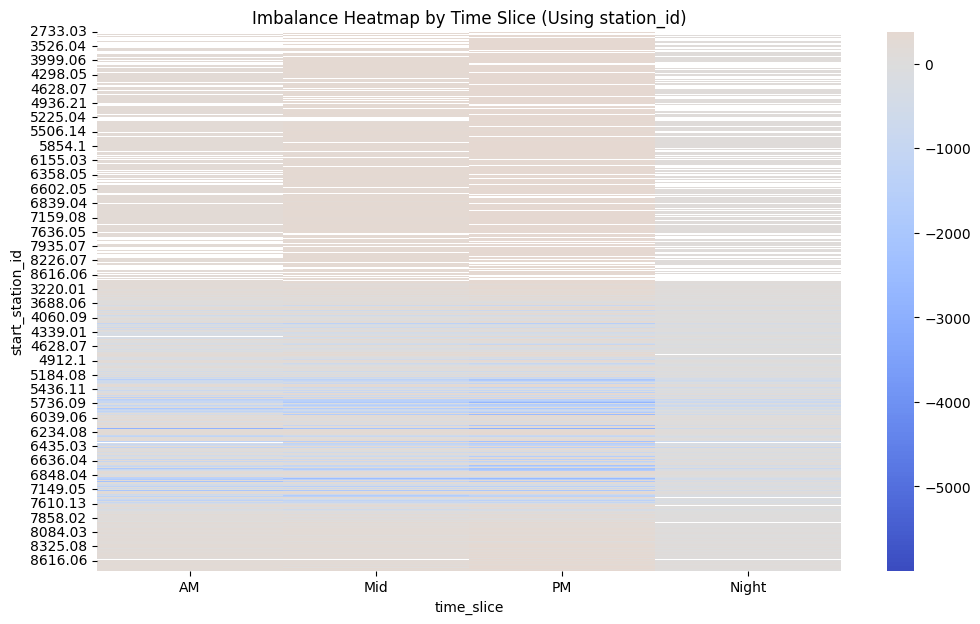

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/krant/Downloads/2025-citibike-tripdata.csv")

df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])
df["date"] = df["started_at"].dt.date

departures = df.groupby("start_station_id").size().rename("departures")
arrivals = df.groupby("end_station_id").size().rename("arrivals")

imbalance = pd.concat([arrivals, departures], axis=1).fillna(0)
imbalance["imbalance"] = imbalance["arrivals"] - imbalance["departures"]

imbalance.reset_index().rename(columns={"start_station_id": "station_id"}) \
    .to_csv("imbalance_tables.csv", index=False)

top_deficits = imbalance.sort_values("imbalance").head(15)
top_surplus = imbalance.sort_values("imbalance", ascending=False).head(15)

print("=== Stations That Keep Emptying (Deficits) ===")
display(top_deficits)

print("\n=== Stations That Keep Overfilling (Surplus) ===")
display(top_surplus)

daily_counts = df.groupby(["date", "start_station_id"]) \
                 .size().unstack(fill_value=0)

volatility = daily_counts.std().sort_values(ascending=False)

print("\n=== Most Volatile Stations (Day-to-Day Changes) ===")
display(volatility.head(15))

df["is_weekend"] = df["started_at"].dt.weekday >= 5

def time_slice(hour):
    if 5 <= hour < 11:
        return "AM"
    elif 11 <= hour < 16:
        return "Mid"
    elif 16 <= hour < 21:
        return "PM"
    else:
        return "Night"

df["time_slice"] = df["started_at"].dt.hour.apply(time_slice)

slice_imbalance = (
    df.groupby(["start_station_id", "time_slice"]).size().rename("departures")
      .to_frame()
      .join(df.groupby(["end_station_id", "time_slice"]).size().rename("arrivals"))
      .fillna(0)
)

slice_imbalance["imbalance"] = slice_imbalance["arrivals"] - slice_imbalance["departures"]
slice_imbalance = slice_imbalance.reset_index()

print("\nTime-slice imbalance sample:")
display(slice_imbalance.head())

daily_dep = (
    df.groupby([df["started_at"].dt.date, "start_station_id"])
      .size()
      .rename("departures")
)

daily_arr = (
    df.groupby([df["ended_at"].dt.date, "end_station_id"])
      .size()
      .rename("arrivals")
)

daily_dep.index = daily_dep.index.set_names(["date", "station_id"])
daily_arr.index = daily_arr.index.set_names(["date", "station_id"])

daily = pd.concat([daily_dep, daily_arr], axis=1).fillna(0)
daily["imbalance"] = daily["arrivals"] - daily["departures"]

mag = daily.groupby("station_id")["imbalance"].mean().abs().rename("magnitude")
vol = daily.groupby("station_id")["imbalance"].std().rename("volatility")

priority = pd.concat([mag, vol], axis=1).fillna(0)
priority["truck_priority_score"] = 0.6 * priority["magnitude"] + 0.4 * priority["volatility"]
priority = priority.sort_values("truck_priority_score", ascending=False)

print("\nTop 15 high-stress stations:")
display(priority.head(15))

daily2 = pd.DataFrame()
daily2["arrivals"] = df.groupby([df["ended_at"].dt.date, "end_station_id"]).size()
daily2["departures"] = df.groupby([df["started_at"].dt.date, "start_station_id"]).size()
daily2 = daily2.fillna(0)

daily2.index = daily2.index.set_names(["date", "station_id"])

vol_arr = daily2.groupby("station_id")["arrivals"].std().rename("arrival_vol")
vol_dep = daily2.groupby("station_id")["departures"].std().rename("departure_vol")

vol_combo = pd.concat([vol_arr, vol_dep], axis=1).fillna(0)
vol_combo["combined_volatility"] = vol_combo.mean(axis=1)

print("\nCombined arrival + departure volatility:")
display(vol_combo.head())

pivot = slice_imbalance.pivot_table(
    index="start_station_id",
    columns="time_slice",
    values="imbalance",
    aggfunc="mean"
).reindex(columns=["AM", "Mid", "PM", "Night"])

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap="coolwarm", center=0)
plt.title("Imbalance Heatmap by Time Slice (Using station_id)")
plt.show()


PART F — Network Inference & Link Prediction

For Part F, I build a station network from the trip data and then run three link-prediction methods: Adamic–Adar, Preferential Attachment, and Common Neighbors. These scores help me find “emerging” connections between stations, meaning station pairs that might grow into strong corridors in the future even if they don’t currently have many trips.

To evaluate these methods in a more realistic way, I divide the dataset into a training period (January-March) and a testing period (April). I construct a weighted network from the training data and a separate network from the April data, and then identify the set of emerging edges-station pairs that appear in April but were not present during the earlier months. These emerging edges serve as the ground-truth future connections that the link-prediction methods aim to forecast.

After computing the three predictor scores for all candidate pairs, I merge the results into a single table and apply a geographic distance filter. Using each station’s latitude and longitude, I keep only pairs that lie within approximately 2 kilometers of each other. This makes the predictions more operationally meaningful by removing unrealistic long-distance connections.

Next, I create a final combined score for each station pair by summing the three predictors. I then rank all candidate pairs by this score and examine the top 100 predicted links. To measure how well the methods perform, I compute Precision@100, which reports how many of these top predicted links actually became emerging edges in April. This gives a clear, quantitative way to see how effective the link-prediction approach is for forecasting future Citi Bike demand patterns.

In addition to the evaluation, I also generate a Top 10 recommended station pair list and create a visualizations: a score-distribution plot. These help me better understand how the prediction scores are distributed and what the strongest emerging connections look like in the network.

Training rows: 2999793
Test rows: 724596
Emerging edges: 47040
Prediction candidate pairs: 2284273
Filtered candidates: 22324

Top-20 Adamic–Adar:


,u,v,aa_score
1378239,4683.02,nan,84.505884
2218061,6822.09,5492.05,83.971925
2222468,6164.09,nan,80.978388
2246272,nan,6379.03,79.331884
84097,4637.06,5267.08,78.440972
1155500,4611.03,5195.06,78.282296
323610,4479.10,5235.05,78.161455
1395609,6072.06,6822.09,77.995979
3554,5329.03,6822.09,77.882002
1410070,5207.01,5235.05,77.694516



Top-20 Preferential Attachment:


,u,v,pa_score
1378239,4683.02,nan,971106
486284,4546.06,nan,835636
1443313,4116.09,nan,831358
2092331,4864.09,nan,831358
2246274,nan,4010.15,817098
1051860,5148.03,nan,817098
1740521,4074.14,nan,781448
2122682,4060.09,nan,772892
2222468,6164.09,nan,772892
2144056,4522.07,nan,770040



Top-20 Common Neighbors:


,u,v,cn_score
2218061,6822.09,5492.05,523
1378239,4683.02,nan,519
2222468,6164.09,nan,506
2246272,nan,6379.03,492
1395609,6072.06,6822.09,487
3554,5329.03,6822.09,487
1155500,4611.03,5195.06,484
1410070,5207.01,5235.05,483
323610,4479.10,5235.05,483
84097,4637.06,5267.08,483



Precision@100: 0.33
Recall@100: 0.0007015306122448979
Hits: 33 of 100


,u,v,aa_score,pa_score,cn_score,is_close,final_score
798993,5406.02,4936.01,61.150240,378498,384,True,378943.150240
1112440,6230.02,5944.01,48.317719,374706,302,True,375056.317719
874139,5584.05,5276.04,56.297308,370804,355,True,371215.297308
1441661,6830.04,6432.08,61.098083,360036,382,True,360479.098083
789392,5374.01,4821.10,53.204933,356569,334,True,356956.204933
748755,5270.07,5584.04,68.193895,353508,428,True,354004.193895
777643,5348.02,5545.04,49.965929,350400,315,True,350764.965929
812390,5436.09,5276.04,52.556201,346655,331,True,347038.556201
751744,5276.04,5506.14,52.502063,341981,331,True,342364.502063
751745,5276.04,5545.04,54.158290,341202,342,True,341598.158290



Top 10 Recommended Station Connections:

798994. 5406.02  ->  4936.01   (score=378943.15)
1112441. 6230.02  ->  5944.01   (score=375056.32)
874140. 5584.05  ->  5276.04   (score=371215.30)
1441662. 6830.04  ->  6432.08   (score=360479.10)
789393. 5374.01  ->  4821.10   (score=356956.20)
748756. 5270.07  ->  5584.04   (score=354004.19)
777644. 5348.02  ->  5545.04   (score=350764.97)
812391. 5436.09  ->  5276.04   (score=347038.56)
751745. 5276.04  ->  5506.14   (score=342364.50)
751746. 5276.04  ->  5545.04   (score=341598.16)


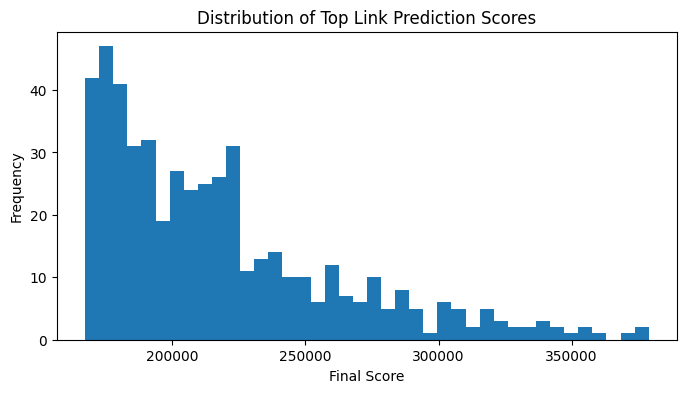

In [8]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

df["month"] = df["started_at"].dt.month

df["start_station_id"] = df["start_station_id"].astype(str)
df["end_station_id"] = df["end_station_id"].astype(str)

train = df[df["month"].isin([1, 2, 3])]
test = df[df["month"] == 4]

print("Training rows:", len(train))
print("Test rows:", len(test))

def build_graph(data):
    G = nx.Graph()
    grouped = data.groupby(["start_station_id", "end_station_id"]).size()
    for (u, v), w in grouped.items():
        if u != v:
            if G.has_edge(u, v):
                G[u][v]["weight"] += w
            else:
                G.add_edge(u, v, weight=w)
    return G

G_train = build_graph(train)
G_test = build_graph(test)

train_edges = set(tuple(sorted(e)) for e in G_train.edges())
test_edges = set(tuple(sorted(e)) for e in G_test.edges())
emerging_edges = set(test_edges - train_edges)

print("Emerging edges:", len(emerging_edges))

aa = list(nx.adamic_adar_index(G_train))
aa_df = pd.DataFrame([(u, v, s) for u, v, s in aa],
                     columns=["u", "v", "aa_score"])

pa = list(nx.preferential_attachment(G_train))
pa_df = pd.DataFrame([(u, v, s) for u, v, s in pa],
                     columns=["u", "v", "pa_score"])

cn_rows = []
for u, v in nx.non_edges(G_train):
    cn_rows.append((u, v, len(list(nx.common_neighbors(G_train, u, v)))))

cn_df = pd.DataFrame(cn_rows, columns=["u", "v", "cn_score"])

pred = aa_df.merge(pa_df, on=["u", "v"], how="outer").merge(cn_df, on=["u", "v"], how="outer")
pred = pred.fillna(0)

print("Prediction candidate pairs:", len(pred))

coords = df.groupby("start_station_id")[["start_lat", "start_lng"]].mean()

def close(u, v, max_km=2):
    if u not in coords.index or v not in coords.index:
        return False
    x1, y1 = coords.loc[u]
    x2, y2 = coords.loc[v]
    d = np.sqrt((x1 - x2)**2 + (y1 - y2)**2) * 111
    return d <= max_km

pred["is_close"] = pred.apply(lambda r: close(r.u, r.v), axis=1)
pred = pred[pred["is_close"]]

print("Filtered candidates:", len(pred))

pred["final_score"] = pred["aa_score"] + pred["pa_score"] + pred["cn_score"]
pred_sorted = pred.sort_values("final_score", ascending=False)

pred_sorted.to_csv("predicted_links.csv", index=False)

top20_aa = aa_df.sort_values("aa_score", ascending=False).head(20)
top20_pa = pa_df.sort_values("pa_score", ascending=False).head(20)
top20_cn = cn_df.sort_values("cn_score", ascending=False).head(20)

print("\nTop-20 Adamic–Adar:")
display(top20_aa)

print("\nTop-20 Preferential Attachment:")
display(top20_pa)

print("\nTop-20 Common Neighbors:")
display(top20_cn)

K = 100
topK = pred_sorted.head(K)

topK_pairs = set(tuple(sorted((row.u, row.v))) for _, row in topK.iterrows())

hits = len(topK_pairs & emerging_edges)
precision_at_k = hits / K
recall_at_k = hits / len(emerging_edges) if len(emerging_edges) > 0 else 0

print("\nPrecision@100:", precision_at_k)
print("Recall@100:", recall_at_k)
print("Hits:", hits, "of", K)

pd.set_option("display.max_rows", 200)
display(topK)

print("\nTop 10 Recommended Station Connections:\n")
top10 = topK.head(10)[["u", "v", "final_score"]]

for i, row in top10.iterrows():
    print(f"{i+1}. {row.u}  ->  {row.v}   (score={row.final_score:.2f})")

plt.figure(figsize=(8,4))
pred_sorted["final_score"].head(500).plot(kind="hist", bins=40)
plt.title("Distribution of Top Link Prediction Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()


Map Visualization of Top 100 Predicted Links 

In [10]:
import plotly.graph_objects as go

# --------------------------
# 1. Build station coordinate dict
# --------------------------

station_pos = (
    df.groupby("start_station_id")[["start_lat", "start_lng"]]
      .mean()
      .rename(columns={"start_lat": "lat", "start_lng": "lon"})
      .to_dict("index")
)

print("Stations with coordinates:", len(station_pos))

# --------------------------
# 2. Pick top predicted edges 
# --------------------------

K_map = 100
edges_map = topK.head(K_map)

print("Edges plotted on map:", len(edges_map))

# --------------------------
# 3. Build edge coordinate arrays
# --------------------------

edge_lat = []
edge_lon = []

for _, row in edges_map.iterrows():
    u, v = row["u"], row["v"]

    if (u not in station_pos) or (v not in station_pos):
        continue

    lat_u, lon_u = station_pos[u]["lat"], station_pos[u]["lon"]
    lat_v, lon_v = station_pos[v]["lat"], station_pos[v]["lon"]

    edge_lat += [lat_u, lat_v, None]
    edge_lon += [lon_u, lon_v, None]

edge_trace = go.Scattermapbox(
    lat=edge_lat,
    lon=edge_lon,
    mode="lines",
    line=dict(width=1.5, color="rgba(0,0,0,0.25)"),
    hoverinfo="none",
    name="Predicted links"
)

# --------------------------
# 4. Node markers — stations used in the top predicted edges
# --------------------------

nodes_used = sorted(set(edges_map["u"]).union(set(edges_map["v"])))

node_lat = []
node_lon = []
node_text = []

for n in nodes_used:
    if n not in station_pos:
        continue

    lat, lon = station_pos[n]["lat"], station_pos[n]["lon"]
    node_lat.append(lat)
    node_lon.append(lon)
    node_text.append(f"Station ID: {n}")

node_trace = go.Scattermapbox(
    lat=node_lat,
    lon=node_lon,
    mode="markers",
    marker=dict(
        size=9,
        color="blue",
        opacity=0.8
    ),
    text=node_text,
    hoverinfo="text",
    name="Stations"
)

# --------------------------
# 5. Center on NYC
# --------------------------

center_lat = df["start_lat"].mean()
center_lon = df["start_lng"].mean()

fig_map = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=f"Top {K_map} Predicted Links (Map View)",
        showlegend=False,
        margin=dict(l=0, r=0, t=40, b=0),
        mapbox=dict(
            style="open-street-map",
            center=dict(lat=center_lat, lon=center_lon),
            zoom=11
        )
    )
)

fig_map.show()


Stations with coordinates: 2256
Edges plotted on map: 100


/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_6521/3965238514.py:44: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_6521/3965238514.py:72: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

